**<h3 style="color:orange">Please make sure any LLM coding assistant like Github Copilot or Cursus is turned OFF!</h2>**

**<h4 style="color:orange">We want you to learn and think critically, not to let LLMs do your work for you.</h4>**

**<h4 style="color:orange">Ask your group members or the internet for help, BEFORE asking your favorite chatbot.</h4>**

<img src="../figures/copilot.png">

# Assignment 1 Part 1: Learning Eulerian dynamics with neural networks

In this assignment, you will learn a discrete time-evolution operator for the two-dimensional Navier-Stokes equations. The state is represented in an **Eulerian** frame: vorticity is stored at fixed points on a spatial grid rather than by following fluid particles. Given a vorticity field $\omega_t(x,y)$, the prediction task is

$$\mathcal{G}_\theta:\omega_t \mapsto \widehat{\omega}_{t+1}.$$

You will study how architectural choices and training strategies affect one-step accuracy, autoregressive stability, and computational efficiency. The notebook uses trajectories from a two-dimensional Navier-Stokes benchmark and compares a periodic U-Net, a full spatial Transformer, and a Transolver-inspired physics-slice Transformer.

## What is provided

The data preparation, normalization, train/validation/test split, metrics, visualization functions, and rollout utilities are fully implemented. The following two baseline models and their complete training and evaluation pipelines are also provided:

- **Periodic U-Net:** a convolutional model with circular padding, multiple spatial resolutions, and skip connections.
- **Spatial Transformer:** a token-based model that applies full self-attention across all grid points.

Run these sections to train and evaluate both baselines. Their one-step results, rollout errors, and runtime provide the reference values for your implementations. You are not expected to reimplement these models.

## What you must implement

The assignment contains two implementation tasks:

1. **Physics-slice Transformer (Section 8).** Implement `PhysicsSliceAttention`, `PhysicsSliceBlock`, and `PhysicsSliceTransformer`. The mathematical construction, tensor shapes, class interfaces, and surrounding training and evaluation code are provided. You must complete the three model classes, train the model, and compare its accuracy and speed with the supplied baselines.

2. **Pushforward training (Section 10).** Design and implement pushforward training for a new physics-slice Transformer. This is an open-ended task: you must implement the required dataset, one-epoch training procedure, pushforward-step scheduler, validation and checkpointing logic, and any other necessary training code. Evaluate both one-step prediction and autoregressive rollout, then compare the result with the ordinarily trained physics-slice Transformer from Section 8.

## Working and submission expectations

Run the notebook in order because later sections reuse models, variables, and evaluation results from earlier sections. A GPU is strongly recommended for training. Keep the supplied dataset split, model-size hyperparameters, and evaluation definitions unchanged so that comparisons remain meaningful. 

## 1. Setup and data

We begin by importing the required libraries, fixing random seeds, and selecting a GPU when one is available.

In [1]:
from pathlib import Path
import random

import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import copy
import time
import collections

from huggingface_hub import hf_hub_download

/home/ivan/uni/MLS/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch version:", torch.__version__)
print("Device:", device)

PyTorch version: 2.14.0+cu132
Device: cuda


### Downloading and inspecting the dataset

The dataset is downloaded from the standard PDE benchmark collection and stored locally. We inspect its variables, dimensions, and an example transition before constructing training samples.

> The seed controls the main random-number generators, but exact reproducibility can still depend on hardware and low-level CUDA operations.

In [3]:
DATA_DIR = Path("../data/navier_stokes")
DATA_DIR.mkdir(parents=True, exist_ok=True)

data_path = hf_hub_download(
    repo_id="kmario23/standard-pde-benchmark",
    repo_type="dataset",
    filename="ns/NavierStokes_V1e-5_N1200_T20.mat",
    local_dir=DATA_DIR,
)

data_path = Path(data_path)

print("Dataset path:")
print(data_path)

print(f"\nFile size: {data_path.stat().st_size / 1024**2:.1f} MB")

Dataset path:
/home/ivan/uni/MLS/repo/data/navier_stokes/ns/NavierStokes_V1e-5_N1200_T20.mat

File size: 393.8 MB


In [4]:
data = sio.loadmat(data_path)

print("Variables stored in the .mat file:")
print(data.keys())

Variables stored in the .mat file:
dict_keys(['__header__', '__version__', '__globals__', 'a', 'u', 't'])


In [5]:
initial_vorticity = data["a"]   # omega(x, y, 0)
vorticity = data["u"]           # omega(x, y, t_1), ..., omega(x, y, t_20)

print("Initial conditions:", initial_vorticity.shape)
print("Trajectories:      ", vorticity.shape)
print("dtype:             ", vorticity.dtype)

Initial conditions: (1200, 64, 64)
Trajectories:       (1200, 64, 64, 20)
dtype:              float32


In [6]:
n_trajectories, nx, ny, n_timesteps = vorticity.shape

print("Number of trajectories :", n_trajectories)
print("Spatial resolution     :", nx, "x", ny)
print("Number of time steps   :", n_timesteps)

Number of trajectories : 1200
Spatial resolution     : 64 x 64
Number of time steps   : 20


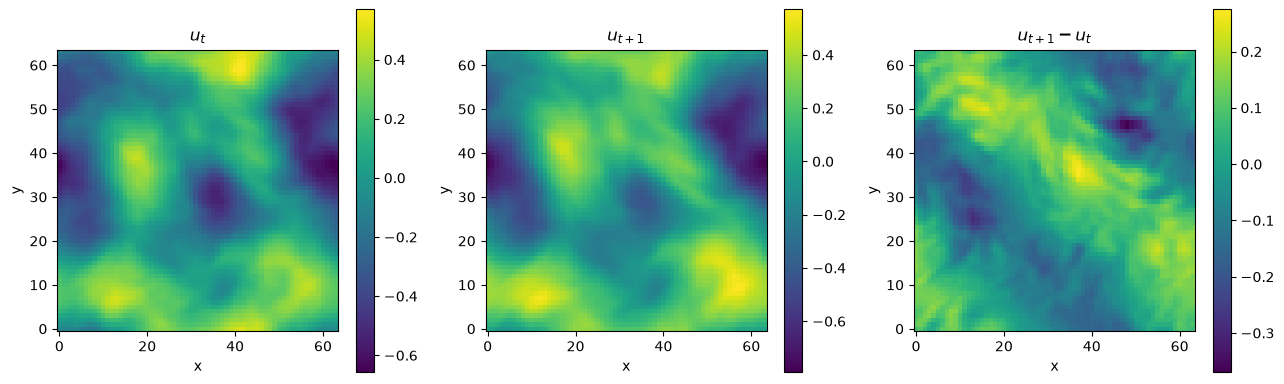

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

im0 = axes[0].imshow(vorticity[0,:,:,0], origin="lower")
axes[0].set_title(r"$u_t$")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(vorticity[0,:,:,1], origin="lower")
axes[1].set_title(r"$u_{t+1}$")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
plt.colorbar(im1, ax=axes[1])

difference = vorticity[0,:,:,1] - vorticity[0,:,:,0]
im2 = axes[2].imshow(difference, origin="lower")
axes[2].set_title(r"$u_{t+1} - u_t$")
axes[2].set_xlabel("x")
axes[2].set_ylabel("y")
plt.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.show()

## 2. From trajectories to supervised examples

Each simulation contains an initial condition $\omega_0$ and 20 later states $\omega_1,\ldots,\omega_{20}$. We convert every trajectory into 20 adjacent pairs

$$ (\omega_0,\omega_1), (\omega_1,\omega_2),\ldots,(\omega_{19},\omega_{20}). $$

The split is performed by **trajectory**, not by individual pairs. This prevents states from the same simulation appearing in both training and evaluation data. We also subsample the grid from $64\times64$ to $32\times32$ and compute normalization statistics using training data only.

In [8]:
N_TRAIN = 900
N_VAL = 100
N_TEST = 200

train_indices = np.arange(0, 900)
val_indices = np.arange(900, 1000)
test_indices = np.arange(1000, 1200)

print("Train trajectories:", len(train_indices))
print("Val trajectories:  ", len(val_indices))
print("Test trajectories: ", len(test_indices))

Train trajectories: 900
Val trajectories:   100
Test trajectories:  200


In [9]:
SPATIAL_STRIDE = 2

train_a = initial_vorticity[:N_TRAIN, ::SPATIAL_STRIDE, ::SPATIAL_STRIDE]

train_u = vorticity[
    :N_TRAIN,
    ::SPATIAL_STRIDE,
    ::SPATIAL_STRIDE,
    :
]

n_values = train_a.size + train_u.size

sum_values = (
    train_a.astype(np.float64).sum()
    + train_u.astype(np.float64).sum()
)

sum_squared = (
    np.square(train_a.astype(np.float64)).sum()
    + np.square(train_u.astype(np.float64)).sum()
)

omega_mean = sum_values / n_values
omega_var = sum_squared / n_values - omega_mean**2
omega_std = np.sqrt(omega_var)

print(f"Training mean: {omega_mean:.6f}")
print(f"Training std:  {omega_std:.6f}")

Training mean: 0.000019
Training std:  1.105457


In [10]:
# Always reuse training-set statistics for validation and test data.
# Computing new statistics on those splits would leak information.
def normalize(x):
    return (x - omega_mean) / omega_std


def denormalize(x):
    return x * omega_std + omega_mean

### Dataset and data loaders

The custom PyTorch dataset maps a single integer index to a trajectory and time step. For the first transition the input comes from `a`; later inputs come from the preceding slice of `u`.

A channel dimension is added because PyTorch convolutional layers expect tensors ordered as `[batch, channels, height, width]`.

In [11]:
class NavierStokesOneStepDataset(Dataset):
    """
    Dataset of one-step vorticity transitions:

        omega_t -> omega_{t+1}

    Each trajectory contains:
        omega_0 = initial_vorticity
        omega_1, ..., omega_20 = vorticity[..., 0:20]

    Therefore each trajectory gives 20 transitions.
    """

    def __init__(
        self,
        initial_vorticity,
        vorticity,
        trajectory_indices,
        mean,
        std,
        spatial_stride=1,
    ):
        self.initial_vorticity = initial_vorticity
        self.vorticity = vorticity
        self.trajectory_indices = np.asarray(trajectory_indices)

        self.mean = mean
        self.std = std
        self.spatial_stride = spatial_stride

        self.n_transitions = vorticity.shape[-1]  # 20


    def __len__(self):
        return len(self.trajectory_indices) * self.n_transitions


    def __getitem__(self, idx):

        # Which trajectory?
        trajectory_position = idx // self.n_transitions

        # Which transition inside that trajectory?
        t = idx % self.n_transitions

        trajectory_idx = self.trajectory_indices[trajectory_position]

        # -------------------------------------------------
        # Construct omega_t
        # -------------------------------------------------

        if t == 0:
            # omega_0 comes from "a"
            x = self.initial_vorticity[
                trajectory_idx,
                ::self.spatial_stride,
                ::self.spatial_stride,
            ]

        else:
            # omega_t is stored at u[..., t-1]
            x = self.vorticity[
                trajectory_idx,
                ::self.spatial_stride,
                ::self.spatial_stride,
                t - 1,
            ]

        # -------------------------------------------------
        # omega_{t+1}
        # -------------------------------------------------

        y = self.vorticity[
            trajectory_idx,
            ::self.spatial_stride,
            ::self.spatial_stride,
            t,
        ]

        # Convert to float32
        x = x.astype(np.float32)
        y = y.astype(np.float32)

        # Normalize
        x = (x - self.mean) / self.std
        y = (y - self.mean) / self.std

        # Convert to tensors
        x = torch.from_numpy(x)
        y = torch.from_numpy(y)

        # Add channel dimension:
        #
        # [H, W] -> [1, H, W]
        #
        x = x.unsqueeze(0)
        y = y.unsqueeze(0)

        return x, y

In [12]:
train_dataset = NavierStokesOneStepDataset(
    initial_vorticity=initial_vorticity,
    vorticity=vorticity,
    trajectory_indices=train_indices,
    mean=omega_mean,
    std=omega_std,
    spatial_stride=SPATIAL_STRIDE,
)

val_dataset = NavierStokesOneStepDataset(
    initial_vorticity=initial_vorticity,
    vorticity=vorticity,
    trajectory_indices=val_indices,
    mean=omega_mean,
    std=omega_std,
    spatial_stride=SPATIAL_STRIDE,
)

test_dataset = NavierStokesOneStepDataset(
    initial_vorticity=initial_vorticity,
    vorticity=vorticity,
    trajectory_indices=test_indices,
    mean=omega_mean,
    std=omega_std,
    spatial_stride=SPATIAL_STRIDE,
)

In [13]:
print("Training samples:  ", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Test samples:      ", len(test_dataset))

Training samples:   18000
Validation samples: 2000
Test samples:       4000


In [14]:
x, y = train_dataset[0]

print("Input shape: ", x.shape)
print("Target shape:", y.shape)
print("Input dtype: ", x.dtype)

Input shape:  torch.Size([1, 32, 32])
Target shape: torch.Size([1, 32, 32])
Input dtype:  torch.float64


In [15]:
BATCH_SIZE = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
)

In [16]:
x_batch, y_batch = next(iter(train_loader))

print("Input batch: ", x_batch.shape)
print("Target batch:", y_batch.shape)

Input batch:  torch.Size([128, 1, 32, 32])
Target batch: torch.Size([128, 1, 32, 32])


In [17]:
# Keep one value per field so aggregation across samples remains explicit.
def mse_per_sample(pred, target):
    """
    pred, target: [B, C, H, W]

    Returns MSE for each sample:
    shape [B]
    """
    return (
        (pred - target)
        .pow(2)
        .flatten(1)
        .mean(dim=1)
    )


def relative_l2_error(pred, target, eps=1e-8):
    """
    Relative L2 error for each sample.

        ||pred - target||_2
        -------------------
            ||target||_2
    """

    diff_norm = torch.linalg.vector_norm(
        (pred - target).flatten(1),
        dim=1,
    )

    target_norm = torch.linalg.vector_norm(
        target.flatten(1),
        dim=1,
    )

    return diff_norm / (target_norm + eps)

## 3. A periodic U-Net

A U-Net combines local convolutions with information at several spatial scales. The encoder reduces resolution, the bottleneck processes coarse features, and the decoder reconstructs a full-resolution field using skip connections.

The physical domain is periodic. Circular padding wraps values from one side of the grid to the other instead of introducing artificial zeros at the boundary.

The network predicts a residual:

$$\widehat{\omega}_{t+1}=\omega_t+\Delta\omega_\theta(\omega_t).$$

This is a useful inductive bias when consecutive states are similar.

In [18]:
class PeriodicConv2d(nn.Module):
    """
    2D convolution with periodic (circular) boundary conditions.
    """

    def __init__(
        self,
        in_channels,
        out_channels,
        kernel_size=3,
        bias=True,
    ):
        super().__init__()

        self.padding = kernel_size // 2

        self.conv = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=kernel_size,
            padding=0,
            bias=bias,
        )

    def forward(self, x):

        # Periodic padding:
        # left, right, top, bottom
        x = F.pad(
            x,
            (
                self.padding,
                self.padding,
                self.padding,
                self.padding,
            ),
            mode="circular",
        )

        return self.conv(x)

In [19]:
class DoubleConv(nn.Module):
    def __init__(
        self,
        in_channels,
        out_channels,
    ):
        super().__init__()

        self.block = nn.Sequential(

            PeriodicConv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                bias=False,
            ),

            nn.GroupNorm(
                num_groups=7,
                num_channels=out_channels,
            ),

            nn.GELU(),

            PeriodicConv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                bias=False,
            ),

            nn.GroupNorm(
                num_groups=7,
                num_channels=out_channels,
            ),

            nn.GELU(),
        )

    def forward(self, x):
        return self.block(x)

In [20]:
class Down(nn.Module):
    def __init__(
        self,
        in_channels,
        out_channels,
    ):
        super().__init__()

        self.pool = nn.MaxPool2d(2)

        self.conv = DoubleConv(
            in_channels,
            out_channels,
        )

    def forward(self, x):

        x = self.pool(x)
        x = self.conv(x)

        return x

In [21]:
class Up(nn.Module):
    def __init__(
        self,
        in_channels,
        skip_channels,
        out_channels,
    ):
        super().__init__()

        self.conv = DoubleConv(
            in_channels + skip_channels,
            out_channels,
        )

    def forward(self, x, skip):

        # Upsample to the same resolution
        # as the corresponding encoder feature.
        x = F.interpolate(
            x,
            size=skip.shape[-2:],
            mode="bilinear",
            align_corners=False,
        )

        # Skip connection
        x = torch.cat(
            [skip, x],
            dim=1,
        )

        x = self.conv(x)

        return x

In [22]:
class UNet(nn.Module):

    def __init__(
        self,
        in_channels=1,
        out_channels=1,
        base_channels=7,
    ):
        super().__init__()

        c1 = base_channels
        c2 = base_channels * 2
        c3 = base_channels * 4
        c4 = base_channels * 8

        # -------------------------
        # Encoder
        # -------------------------

        self.enc1 = DoubleConv(
            in_channels,
            c1,
        )

        self.enc2 = Down(
            c1,
            c2,
        )

        self.enc3 = Down(
            c2,
            c3,
        )

        # -------------------------
        # Bottleneck
        # -------------------------

        self.bottleneck = Down(
            c3,
            c4,
        )

        # -------------------------
        # Decoder
        # -------------------------

        self.dec3 = Up(
            in_channels=c4,
            skip_channels=c3,
            out_channels=c3,
        )

        self.dec2 = Up(
            in_channels=c3,
            skip_channels=c2,
            out_channels=c2,
        )

        self.dec1 = Up(
            in_channels=c2,
            skip_channels=c1,
            out_channels=c1,
        )

        # -------------------------
        # Output
        # -------------------------

        self.output = nn.Conv2d(
            c1,
            out_channels,
            kernel_size=1,
        )


    def forward(self, x):

        input_state = x
        # Encoder
        x1 = self.enc1(x)       # [B, 32, H,   W]
        x2 = self.enc2(x1)      # [B, 64, H/2, W/2]
        x3 = self.enc3(x2)      # [B,128, H/4, W/4]

        # Bottleneck
        x4 = self.bottleneck(x3) # [B,256,H/8,W/8]

        # Decoder
        x = self.dec3(x4, x3)
        x = self.dec2(x,  x2)
        x = self.dec1(x,  x1)

        # Predict next vorticity field
        delta = self.output(x)

        return input_state + delta

In [23]:
unet = UNet(
    in_channels=1,
    out_channels=1,
    base_channels=7,
).to(device)
unet.compile()

print(unet)

UNet(
  (enc1): DoubleConv(
    (block): Sequential(
      (0): PeriodicConv2d(
        (conv): Conv2d(1, 7, kernel_size=(3, 3), stride=(1, 1), bias=False)
      )
      (1): GroupNorm(7, 7, eps=1e-05, affine=True, bias=True)
      (2): GELU(approximate='none')
      (3): PeriodicConv2d(
        (conv): Conv2d(7, 7, kernel_size=(3, 3), stride=(1, 1), bias=False)
      )
      (4): GroupNorm(7, 7, eps=1e-05, affine=True, bias=True)
      (5): GELU(approximate='none')
    )
  )
  (enc2): Down(
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (conv): DoubleConv(
      (block): Sequential(
        (0): PeriodicConv2d(
          (conv): Conv2d(7, 14, kernel_size=(3, 3), stride=(1, 1), bias=False)
        )
        (1): GroupNorm(7, 14, eps=1e-05, affine=True, bias=True)
        (2): GELU(approximate='none')
        (3): PeriodicConv2d(
          (conv): Conv2d(14, 14, kernel_size=(3, 3), stride=(1, 1), bias=False)
        )
        (4): GroupNorm(7,

In [24]:
n_params = sum(
    p.numel()
    for p in unet.parameters()
    if p.requires_grad
)

print(f"Trainable parameters: {n_params:,}")

Trainable parameters: 93,738


## 4. Training the U-Net

The model minimizes mean squared error in normalized coordinates. AdamW performs the updates, while cosine annealing gradually lowers the learning rate. The parameters with the lowest validation loss are retained rather than simply using the final epoch.

In [25]:
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
N_EPOCHS = 30

criterion = nn.MSELoss()

optimizer = torch.optim.AdamW(
    unet.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=N_EPOCHS,
)

In [26]:
def train_one_epoch(
    model,
    loader,
    optimizer,
    criterion,
    device,
):
    model.train()

    total_loss = 0.0
    n_samples = 0

    # Each batch contains independent one-step pairs: omega_t -> omega_{t+1}.
    for x, y in loader:

        x = x.to(device).float()
        y = y.to(device).float()

        # -------------------------
        # Forward
        # -------------------------
        pred = model(x)

        loss = criterion(pred, y)

        # -------------------------
        # Backpropagation
        # -------------------------
        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        # -------------------------
        # Statistics
        # -------------------------
        batch_size = x.shape[0]

        total_loss += loss.item() * batch_size
        n_samples += batch_size

    return total_loss / n_samples

In [27]:
@torch.no_grad()
def evaluate_loss(
    model,
    loader,
    criterion,
    device,
):
    model.eval()

    total_loss = 0.0
    n_samples = 0

    for x, y in loader:

        x = x.to(device).float()
        y = y.to(device).float()

        pred = model(x)

        loss = criterion(pred, y)

        batch_size = x.shape[0]

        total_loss += loss.item() * batch_size
        n_samples += batch_size

    return total_loss / n_samples

In [28]:
train_losses = []
val_losses = []
learning_rates = []

best_val_loss = float("inf")
best_model_state = None

start_time = time.time()

for epoch in range(1, N_EPOCHS + 1):

    # -------------------------
    # Train
    # -------------------------
    train_loss = train_one_epoch(
        model=unet,
        loader=train_loader,
        optimizer=optimizer,
        criterion=criterion,
        device=device,
    )

    # -------------------------
    # Validation
    # -------------------------
    val_loss = evaluate_loss(
        model=unet,
        loader=val_loader,
        criterion=criterion,
        device=device,
    )

    # Record history
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    learning_rates.append(
        optimizer.param_groups[0]["lr"]
    )

    # Save best model
    if val_loss < best_val_loss:

        best_val_loss = val_loss

        best_model_state = copy.deepcopy(
            unet.state_dict()
        )

    # Update learning rate
    scheduler.step()

    print(
        f"Epoch {epoch:3d}/{N_EPOCHS} | "
        f"Train loss: {train_loss:.6e} | "
        f"Val loss: {val_loss:.6e} | "
        f"LR: {optimizer.param_groups[0]['lr']:.2e}"
    )


elapsed = time.time() - start_time

print()
print(
    f"Training finished in "
    f"{elapsed / 60:.1f} minutes"
)

print(
    f"Best validation loss: "
    f"{best_val_loss:.6e}"
)

Epoch   1/30 | Train loss: 9.357347e-02 | Val loss: 5.638671e-02 | LR: 9.97e-04
Epoch   2/30 | Train loss: 4.829847e-02 | Val loss: 4.203336e-02 | LR: 9.89e-04
Epoch   3/30 | Train loss: 3.928919e-02 | Val loss: 3.706030e-02 | LR: 9.76e-04
Epoch   4/30 | Train loss: 3.504914e-02 | Val loss: 3.290704e-02 | LR: 9.57e-04
Epoch   5/30 | Train loss: 3.154547e-02 | Val loss: 3.060771e-02 | LR: 9.33e-04
Epoch   6/30 | Train loss: 2.995959e-02 | Val loss: 2.930232e-02 | LR: 9.05e-04
Epoch   7/30 | Train loss: 2.832925e-02 | Val loss: 2.768136e-02 | LR: 8.72e-04
Epoch   8/30 | Train loss: 2.688662e-02 | Val loss: 2.644294e-02 | LR: 8.35e-04
Epoch   9/30 | Train loss: 2.627876e-02 | Val loss: 2.586733e-02 | LR: 7.94e-04
Epoch  10/30 | Train loss: 2.513060e-02 | Val loss: 2.526634e-02 | LR: 7.50e-04
Epoch  11/30 | Train loss: 2.431064e-02 | Val loss: 2.587002e-02 | LR: 7.03e-04
Epoch  12/30 | Train loss: 2.366045e-02 | Val loss: 2.444505e-02 | LR: 6.55e-04
Epoch  13/30 | Train loss: 2.308088e-02 

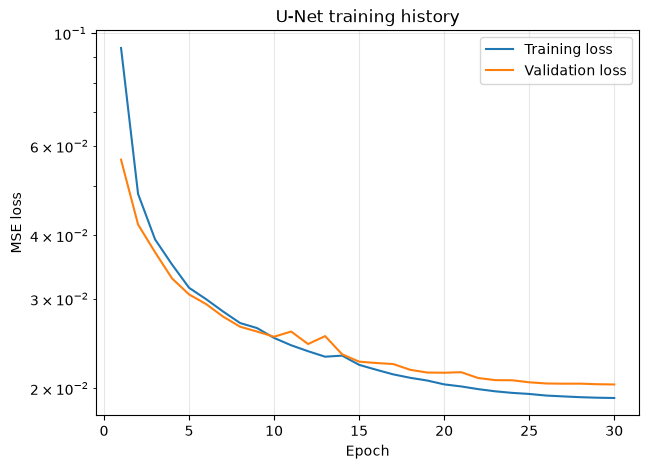

In [29]:
epochs = np.arange(
    1,
    len(train_losses) + 1,
)

plt.figure(figsize=(7, 5))

plt.plot(
    epochs,
    train_losses,
    label="Training loss",
)

plt.plot(
    epochs,
    val_losses,
    label="Validation loss",
)

plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("U-Net training history")
plt.yscale("log")
plt.grid(alpha=0.3)
plt.legend()

plt.show()

In [30]:
unet.load_state_dict(best_model_state)

unet.eval()

print("Best U-Net restored.")

Best U-Net restored.


## 5. One-step evaluation

We first evaluate individual transitions from unseen trajectories. Predictions and targets are converted back to physical units before computing:

- **MSE**, the average squared error per grid point;
- **relative $L^2$ error**, $\lVert\widehat{\omega}-\omega\rVert_2/\lVert\omega\rVert_2$, the error relative to the target magnitude.

Spatial plots can reveal structured errors that a single scalar metric hides.

In [31]:
@torch.no_grad()
def evaluate_one_step(
    model,
    loader,
    mean,
    std,
    device,
):
    model.eval()

    mse_values = []
    rel_l2_values = []

    for x, y in loader:

        x = x.to(device).float()
        y = y.to(device).float()

        # Prediction in normalized space
        pred = model(x)

        # Convert back to physical scale
        pred_phys = pred * std + mean
        y_phys = y * std + mean

        # MSE per sample
        mse = (
            (pred_phys - y_phys)
            .pow(2)
            .flatten(1)
            .mean(dim=1)
        )

        # Relative L2 per sample
        diff_norm = torch.linalg.vector_norm(
            (pred_phys - y_phys).flatten(1),
            dim=1,
        )

        target_norm = torch.linalg.vector_norm(
            y_phys.flatten(1),
            dim=1,
        )

        rel_l2 = diff_norm / (
            target_norm + 1e-8
        )

        mse_values.append(
            mse.cpu()
        )

        rel_l2_values.append(
            rel_l2.cpu()
        )

    mse_values = torch.cat(mse_values)
    rel_l2_values = torch.cat(
        rel_l2_values
    )

    return {
        "MSE": mse_values.mean().item(),
        "Relative L2": (
            rel_l2_values.mean().item()
        ),
    }

In [32]:
unet_test_results = evaluate_one_step(
    model=unet,
    loader=test_loader,
    mean=omega_mean,
    std=omega_std,
    device=device,
)

print("U-Net one-step test results")
print("---------------------------")

for metric, value in unet_test_results.items():
    print(
        f"{metric:12s}: {value:.6e}"
    )

U-Net one-step test results
---------------------------
MSE         : 2.644214e-02
Relative L2 : 1.353959e-01


In [33]:
@torch.no_grad()
def plot_one_step_prediction(
    model,
    dataset,
    sample_idx,
    mean,
    std,
    device,
):

    model.eval()

    x, y = dataset[sample_idx]

    x_batch = (
        x.unsqueeze(0)
        .to(device).float()
    )

    pred = model(x_batch)[0].cpu()

    # Convert to physical units
    x_phys = (
        x * std + mean
    ).squeeze().numpy()

    y_phys = (
        y * std + mean
    ).squeeze().numpy()

    pred_phys = (
        pred * std + mean
    ).squeeze().numpy()

    error = np.abs(
        pred_phys - y_phys
    )

    vmin = min(
        x_phys.min(),
        y_phys.min(),
        pred_phys.min(),
    )

    vmax = max(
        x_phys.max(),
        y_phys.max(),
        pred_phys.max(),
    )

    fig, axes = plt.subplots(
        1,
        4,
        figsize=(16, 4),
    )

    im = axes[0].imshow(
        x_phys,
        origin="lower",
        vmin=vmin,
        vmax=vmax,
    )

    axes[0].set_title(
        r"Input $\omega_t$"
    )

    axes[1].imshow(
        y_phys,
        origin="lower",
        vmin=vmin,
        vmax=vmax,
    )

    axes[1].set_title(
        r"True $\omega_{t+1}$"
    )

    axes[2].imshow(
        pred_phys,
        origin="lower",
        vmin=vmin,
        vmax=vmax,
    )

    axes[2].set_title(
        r"Predicted $\hat{\omega}_{t+1}$"
    )

    err_im = axes[3].imshow(
        error,
        origin="lower",
    )

    axes[3].set_title(
        "Absolute error"
    )

    plt.colorbar(
        im,
        ax=axes[:3],
        shrink=0.8,
    )

    plt.colorbar(
        err_im,
        ax=axes[3],
        shrink=0.8,
    )

    plt.show()

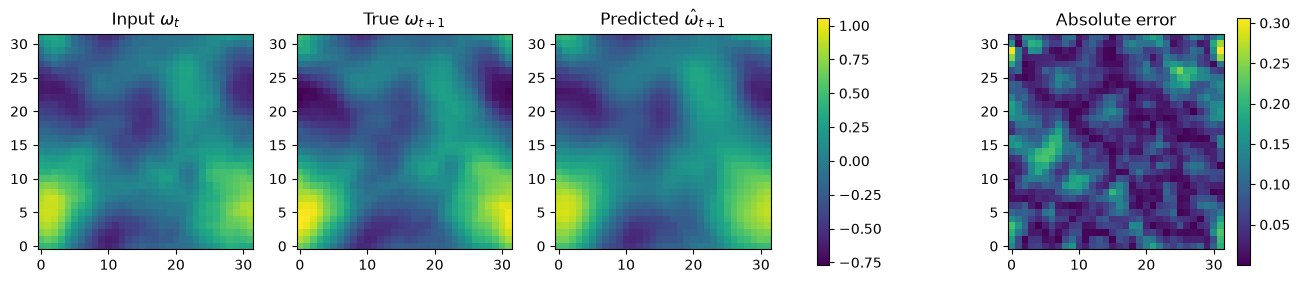

In [34]:
plot_one_step_prediction(
    model=unet,
    dataset=test_dataset,
    sample_idx=100,
    mean=omega_mean,
    std=omega_std,
    device=device,
)

## 6. Multi-step prediction

One-step accuracy does not fully describe a dynamical surrogate. We compare two multi-step modes:

- **Teacher forcing:** every prediction receives the true current state, isolating one-step approximation error.
- **Autoregressive rollout:** every prediction becomes the next input, testing stability and accumulated distribution shift.

A model can perform well under teacher forcing yet drift autoregressively because it was trained on true states but encounters its own imperfect predictions at inference time.

In [35]:
def get_trajectory(
    trajectory_idx,
    initial_vorticity,
    vorticity,
    spatial_stride=1,
):
    """
    Returns a complete trajectory

        omega_0, ..., omega_20

    Shape:
        [21, H, W]
    """

    omega0 = initial_vorticity[
        trajectory_idx,
        ::spatial_stride,
        ::spatial_stride,
    ]

    future = vorticity[
        trajectory_idx,
        ::spatial_stride,
        ::spatial_stride,
        :,
    ]

    # future currently:
    # [H, W, 20]
    #
    # convert to:
    # [20, H, W]

    future = np.moveaxis(
        future,
        -1,
        0,
    )

    trajectory = np.concatenate(
        [
            omega0[None, ...],
            future,
        ],
        axis=0,
    )

    return trajectory.astype(
        np.float32
    )

In [36]:
trajectory = get_trajectory(
    trajectory_idx=test_indices[0],
    initial_vorticity=initial_vorticity,
    vorticity=vorticity,
    spatial_stride=SPATIAL_STRIDE,
)

print(trajectory.shape)

(21, 32, 32)


In [37]:
@torch.no_grad()
def rollout_model(
    model,
    initial_state,
    n_steps,
    mean,
    std,
    device,
):
    """
    Autoregressive rollout.

    initial_state:
        [H, W] in physical units

    Returns:
        [n_steps + 1, H, W]
        in physical units.
    """

    model.eval()

    predictions = [
        initial_state.copy()
    ]

    # Normalize initial condition
    current = (
        initial_state - mean
    ) / std

    current = torch.tensor(
        current,
        dtype=torch.float32,
        device=device,
    )

    current = current[
        None,
        None,
        ...,
    ]

    for _ in range(n_steps):

        # Predict next normalized state
        next_state = model(current)

        # Store physical state
        next_phys = (
            next_state * std + mean
        )

        predictions.append(
            next_phys[
                0, 0
            ].cpu().numpy()
        )

        # IMPORTANT:
        # prediction becomes next input
        current = next_state

    return np.stack(
        predictions,
        axis=0,
    )

In [38]:
@torch.no_grad()
def rollout_model_teacher_forcing(
    model,
    true_trajectory,
    mean,
    std,
    device,
):
    """
    One-step predictions using the TRUE state at every time step.

    This is NOT autoregressive rollout.

    For each t:
        true omega_t -> predicted omega_{t+1}

    Then, for the next prediction, the model receives
    the true omega_{t+1}, not its previous prediction.

    Parameters
    ----------
    model:
        Trained model.

    true_trajectory:
        Array of shape [T, H, W] in physical units.
        For this dataset: [21, H, W].

    mean, std:
        Normalization statistics.

    device:
        torch device.

    Returns
    -------
    predictions:
        Array of shape [T, H, W].

        predictions[0] is set equal to the true initial state
        so that indexing matches the true trajectory.

        predictions[t+1] is the model prediction obtained
        from the TRUE state true_trajectory[t].
    """

    model.eval()

    n_states = true_trajectory.shape[0]

    predictions = [
        true_trajectory[0].copy()
    ]

    for t in range(n_states - 1):

        # ---------------------------------
        # TRUE current state
        # ---------------------------------

        current_true = true_trajectory[t]

        # Normalize
        current = (
            current_true - mean
        ) / std

        # [H, W] -> [1, 1, H, W]
        current = torch.tensor(
            current,
            dtype=torch.float32,
            device=device,
        )[None, None, ...]

        # ---------------------------------
        # One-step prediction
        # ---------------------------------

        next_state = model(current)

        # Convert back to physical units
        next_phys = (
            next_state * std + mean
        )

        next_phys = (
            next_phys[0, 0]
            .cpu()
            .numpy()
        )

        predictions.append(
            next_phys
        )

    return np.stack(
        predictions,
        axis=0,
    )

In [39]:
trajectory_idx = test_indices[1]

true_trajectory = get_trajectory(
    trajectory_idx=trajectory_idx,
    initial_vorticity=initial_vorticity,
    vorticity=vorticity,
    spatial_stride=SPATIAL_STRIDE,
)

pred_trajectory = rollout_model(
    model=unet,
    initial_state=true_trajectory[0],
    n_steps=20,
    mean=omega_mean,
    std=omega_std,
    device=device,
)

teacher_forced_predictions = rollout_model_teacher_forcing(
        model=unet,
        true_trajectory=true_trajectory,
        mean=omega_mean,
        std=omega_std,
        device=device,
    )


print(
    "True trajectory:",
    true_trajectory.shape,
)

print(
    "Predicted trajectory:",
    pred_trajectory.shape,
)


print(
    "Predicted teacher forcing trajectory:",
    teacher_forced_predictions.shape,
)

True trajectory: (21, 32, 32)
Predicted trajectory: (21, 32, 32)
Predicted teacher forcing trajectory: (21, 32, 32)


In [40]:
def trajectory_relative_l2(
    prediction,
    target,
    eps=1e-8,
):
    """
    prediction, target:
        [T, H, W]

    Returns:
        [T]
    """

    diff = prediction - target

    numerator = np.sqrt(
        np.sum(
            diff**2,
            axis=(1, 2),
        )
    )

    denominator = np.sqrt(
        np.sum(
            target**2,
            axis=(1, 2),
        )
    )

    return numerator / (
        denominator + eps
    )

In [41]:
rollout_error = trajectory_relative_l2(
    pred_trajectory,
    true_trajectory,
)

print(rollout_error.shape)

teacher_forcing_error = trajectory_relative_l2(
    teacher_forced_predictions,
    true_trajectory,
)

print(teacher_forcing_error.shape)

(21,)
(21,)


In [42]:
@torch.no_grad()
def evaluate_rollouts(
    model,
    trajectory_indices,
    initial_vorticity,
    vorticity,
    spatial_stride,
    mean,
    std,
    device,
    n_steps=20,
):
    all_errors = []
    all_errors_teacher_forcing = []

    # Retain an error curve for every trajectory before averaging.
    for trajectory_idx in trajectory_indices:

        true_trajectory = get_trajectory(
            trajectory_idx,
            initial_vorticity,
            vorticity,
            spatial_stride,
        )

        pred_trajectory = rollout_model(
            model=model,
            initial_state=true_trajectory[0],
            n_steps=n_steps,
            mean=mean,
            std=std,
            device=device,
        )

        pred_trajectory_teacher_forcing = rollout_model_teacher_forcing(
            model=model,
            true_trajectory=true_trajectory[:n_steps + 1],
            mean=mean,
            std=std,
            device=device,
        )

        errors = trajectory_relative_l2(
            pred_trajectory,
            true_trajectory[
                :n_steps + 1
            ],
        )


        errors_teacher_forcing = trajectory_relative_l2(
            pred_trajectory_teacher_forcing,
            true_trajectory[:n_steps + 1],
        )

        all_errors.append(errors)
        all_errors_teacher_forcing.append(errors_teacher_forcing)

    all_errors = np.stack(
        all_errors,
        axis=0,
    )

    all_errors_teacher_forcing = np.stack(
            all_errors_teacher_forcing,
            axis=0,
        )

    return all_errors, all_errors_teacher_forcing

In [43]:
unet_rollout_errors, unet_teacher_forcing_errors = evaluate_rollouts(
    model=unet,
    trajectory_indices=test_indices,
    initial_vorticity=initial_vorticity,
    vorticity=vorticity,
    spatial_stride=SPATIAL_STRIDE,
    mean=omega_mean,
    std=omega_std,
    device=device,
    n_steps=20,
)

print(
    unet_rollout_errors.shape
)

print(
    unet_teacher_forcing_errors.shape
)

(200, 21)
(200, 21)


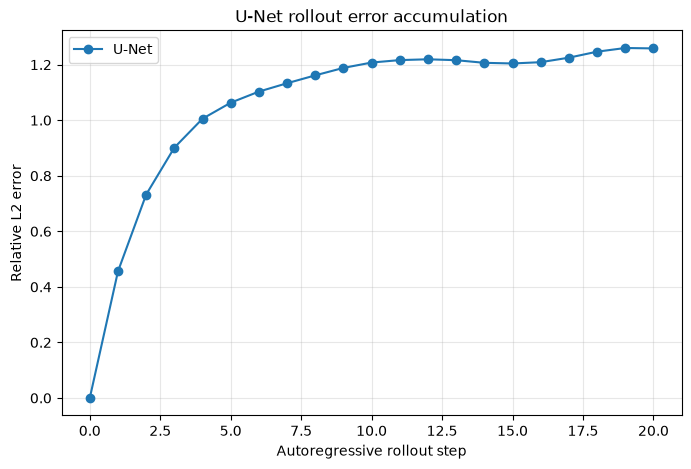

In [44]:
mean_rollout_error = (
    unet_rollout_errors.mean(axis=0)
)

std_rollout_error = (
    unet_rollout_errors.std(axis=0)
)

steps = np.arange(
    len(mean_rollout_error)
)

plt.figure(figsize=(8, 5))

plt.plot(
    steps,
    mean_rollout_error,
    marker="o",
    label="U-Net",
)

# plt.fill_between(
#     steps,
#     mean_rollout_error
#     - std_rollout_error,
#     mean_rollout_error
#     + std_rollout_error,
#     alpha=0.2,
# )

plt.xlabel("Autoregressive rollout step")
plt.ylabel("Relative L2 error")

plt.title(
    "U-Net rollout error accumulation"
)

plt.grid(alpha=0.3)
plt.legend()

plt.show()

In [45]:
def plot_rollout(
    true_trajectory,
    pred_trajectory,
    times=(0, 5, 10, 15, 20),
):

    n = len(times)

    fig, axes = plt.subplots(
        3,
        n,
        figsize=(3 * n, 8),
    )

    vmin = min(
        true_trajectory.min(),
        pred_trajectory.min(),
    )

    vmax = max(
        true_trajectory.max(),
        pred_trajectory.max(),
    )

    for j, t in enumerate(times):

        # -------------------------
        # Ground truth
        # -------------------------

        axes[0, j].imshow(
            true_trajectory[t],
            origin="lower",
            vmin=vmin,
            vmax=vmax,
        )

        axes[0, j].set_title(
            f"True t={t}"
        )

        # -------------------------
        # Prediction
        # -------------------------

        axes[1, j].imshow(
            pred_trajectory[t],
            origin="lower",
            vmin=vmin,
            vmax=vmax,
        )

        axes[1, j].set_title(
            f"Prediction t={t}"
        )

        # -------------------------
        # Error
        # -------------------------

        error = np.abs(
            pred_trajectory[t]
            - true_trajectory[t]
        )

        axes[2, j].imshow(
            error,
            origin="lower",
        )

        axes[2, j].set_title(
            f"|Error| t={t}"
        )

    for ax in axes.flat:
        ax.set_xticks([])
        ax.set_yticks([])

    axes[0, 0].set_ylabel(
        "Ground truth"
    )

    axes[1, 0].set_ylabel(
        "U-Net"
    )

    axes[2, 0].set_ylabel(
        "Absolute error"
    )

    plt.tight_layout()
    plt.show()

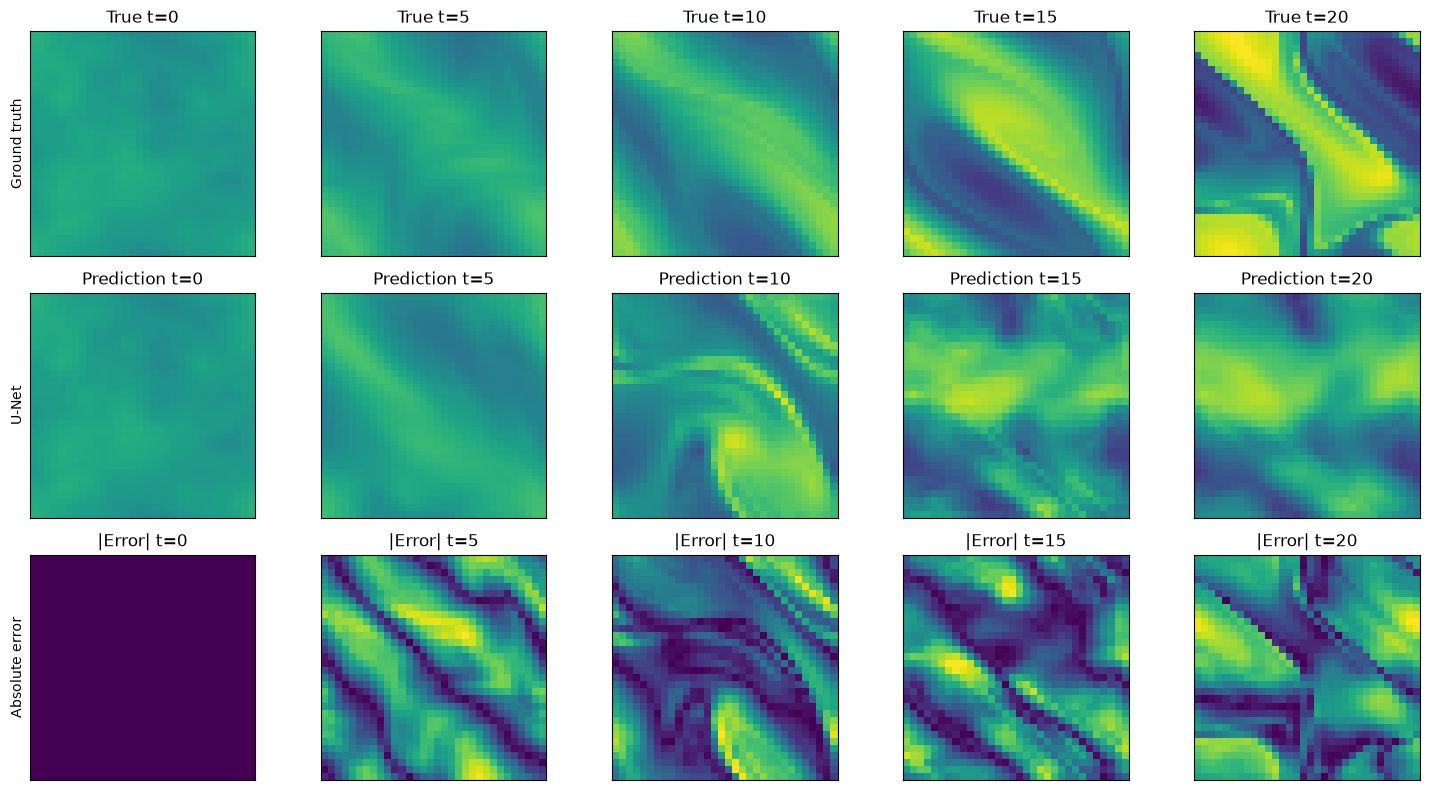

In [46]:
plot_rollout(
    true_trajectory,
    pred_trajectory,
)

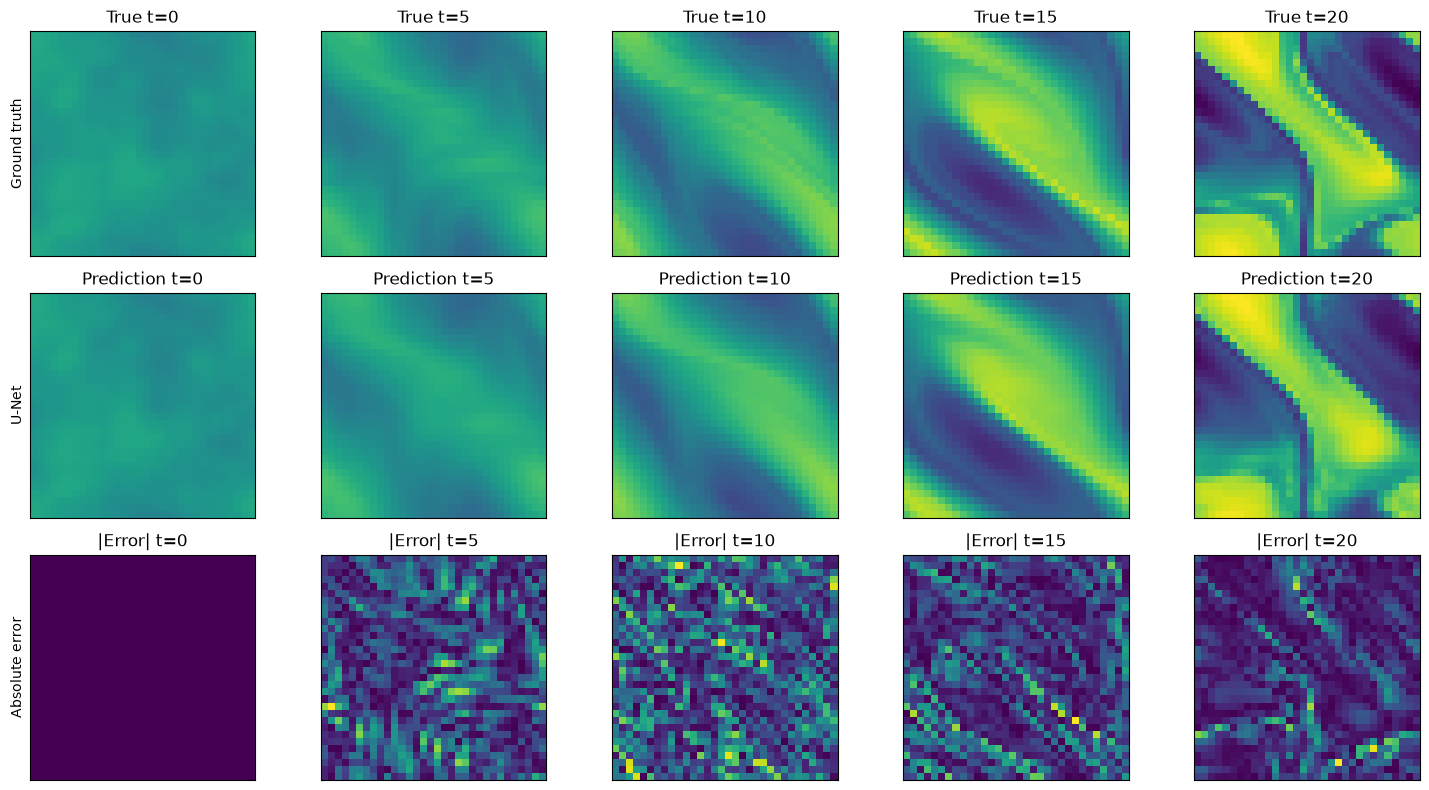

In [47]:
plot_rollout(
    true_trajectory,
    teacher_forced_predictions,
)

## 7. A spatial Transformer

As an alternative to convolution, every grid point becomes a token. At the downsampled resolution, one field produces $32\times32=1024$ tokens. Global self-attention allows every location to interact directly with every other location.

A vorticity value alone does not identify a token's position, so we append periodic coordinates

$$[\sin(2\pi x),\cos(2\pi x),\sin(2\pi y),\cos(2\pi y)].$$

These features respect the topology of the periodic domain. Like the U-Net, the Transformer predicts a residual update.

> Global attention has quadratic cost in the number of tokens. Doubling resolution in both directions creates four times as many tokens and roughly sixteen times as many pairwise attention scores.

In [48]:
def make_periodic_position_features(H, W):
    """
    Create periodic positional features for a H x W grid.

    Returns:
        pos: [H*W, 4]

    Features:
        sin(2*pi*x), cos(2*pi*x),
        sin(2*pi*y), cos(2*pi*y)
    """

    # Map indices to [0, 1); sine and cosine join both ends periodically.
    x = torch.arange(H, dtype=torch.float32) / H
    y = torch.arange(W, dtype=torch.float32) / W

    xx, yy = torch.meshgrid(
        x,
        y,
        indexing="ij",
    )

    pos = torch.stack(
        [
            torch.sin(2 * torch.pi * xx),
            torch.cos(2 * torch.pi * xx),
            torch.sin(2 * torch.pi * yy),
            torch.cos(2 * torch.pi * yy),
        ],
        dim=-1,
    )

    # [H, W, 4] -> [H*W, 4]
    pos = pos.reshape(H * W, 4)

    return pos

In [49]:
class SpatialTransformer(nn.Module):

    def __init__(
        self,
        H,
        W,
        d_model=64,
        n_heads=4,
        n_layers=2,
        dim_feedforward=256,
        dropout=0.0,
        residual_prediction=True,
    ):
        super().__init__()

        self.H = H
        self.W = W
        self.N = H * W

        self.residual_prediction = residual_prediction

        # -----------------------------------
        # Fixed periodic positional features
        # -----------------------------------

        pos = make_periodic_position_features(
            H,
            W,
        )

        self.register_buffer(
            "pos_features",
            pos,
        )

        # omega + 4 positional features
        self.input_projection = nn.Linear(
            5,
            d_model,
        )

        # -----------------------------------
        # Transformer encoder
        # -----------------------------------

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=n_layers,
        )

        self.norm = nn.LayerNorm(
            d_model
        )

        # -----------------------------------
        # Output: one scalar per grid point
        # -----------------------------------

        self.output_projection = nn.Linear(
            d_model,
            1,
        )


    def forward(self, x):
        """
        x:
            [B, 1, H, W]

        output:
            [B, 1, H, W]
        """

        B = x.shape[0]

        input_state = x

        # -----------------------------------
        # Convert grid to tokens
        # -----------------------------------

        # [B, 1, H, W]
        # ->
        # [B, H, W]
        x = x[:, 0]

        # ->
        # [B, N, 1]
        x = x.reshape(
            B,
            self.N,
            1,
        )

        # -----------------------------------
        # Add positional information
        # -----------------------------------

        # [N, 4]
        # ->
        # [B, N, 4]
        pos = self.pos_features.unsqueeze(0).expand(
            B,
            -1,
            -1,
        )

        # [B, N, 5]
        x = torch.cat(
            [x, pos],
            dim=-1,
        )

        # -----------------------------------
        # Token embedding
        # -----------------------------------

        # [B, N, 5]
        # ->
        # [B, N, d_model]
        x = self.input_projection(x)

        # -----------------------------------
        # Global self-attention
        # -----------------------------------

        x = self.transformer(x)

        x = self.norm(x)

        # -----------------------------------
        # Predict delta omega
        # -----------------------------------

        # [B, N, d_model]
        # ->
        # [B, N, 1]
        delta = self.output_projection(x)

        # ->
        # [B, 1, H, W]
        delta = delta.reshape(
            B,
            1,
            self.H,
            self.W,
        )

        if self.residual_prediction:
            return input_state + delta

        return delta

In [50]:
# stride = 1 -> 64 x 64
# stride = 2 -> 32 x 32

H = 64 // SPATIAL_STRIDE
W = 64 // SPATIAL_STRIDE

transformer = SpatialTransformer(
    H=H,
    W=W,
    d_model=64,
    n_heads=4,
    n_layers=2,
    dim_feedforward=256,
    dropout=0.0,
    residual_prediction=True,
).to(device)
transformer.compile()

/tmp/ipykernel_105379/3077198302.py:56: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(


In [51]:
n_params = sum(
    p.numel()
    for p in transformer.parameters()
    if p.requires_grad
)

print(
    f"Transformer parameters: "
    f"{n_params:,}"
)

Transformer parameters: 100,545


### Training the Transformer

We reuse the same data, loss, optimizer family, and learning-rate schedule. Conclusions about architecture quality nevertheless require comparable training budgets and the same validation protocol.

In [52]:
transformer_criterion = nn.MSELoss()

transformer_optimizer = torch.optim.AdamW(
    transformer.parameters(),
    lr=1e-3,
    weight_decay=1e-4,
)

N_TRANSFORMER_EPOCHS = 30

transformer_scheduler = (
    torch.optim.lr_scheduler.CosineAnnealingLR(
        transformer_optimizer,
        T_max=N_TRANSFORMER_EPOCHS,
    )
)

In [53]:
transformer_train_losses = []
transformer_val_losses = []

best_transformer_val_loss = float("inf")
best_transformer_state = None

start_time = time.time()

for epoch in range(
    1,
    N_TRANSFORMER_EPOCHS + 1,
):

    train_loss = train_one_epoch(
        model=transformer,
        loader=train_loader,
        optimizer=transformer_optimizer,
        criterion=transformer_criterion,
        device=device,
    )

    val_loss = evaluate_loss(
        model=transformer,
        loader=val_loader,
        criterion=transformer_criterion,
        device=device,
    )

    transformer_train_losses.append(
        train_loss
    )

    transformer_val_losses.append(
        val_loss
    )

    if val_loss < best_transformer_val_loss:

        best_transformer_val_loss = val_loss

        best_transformer_state = copy.deepcopy(
            transformer.state_dict()
        )

    print(
        f"Epoch "
        f"{epoch:3d}/"
        f"{N_TRANSFORMER_EPOCHS} | "
        f"Train: {train_loss:.6e} | "
        f"Val: {val_loss:.6e} | "
        f"LR: "
        f"{transformer_optimizer.param_groups[0]['lr']:.2e}"
    )

    transformer_scheduler.step()


elapsed = time.time() - start_time

print()
print(
    f"Training time: "
    f"{elapsed / 60:.1f} minutes"
)

print(
    f"Best validation loss: "
    f"{best_transformer_val_loss:.6e}"
)

Epoch   1/30 | Train: 1.965435e-01 | Val: 1.516020e-01 | LR: 1.00e-03
Epoch   2/30 | Train: 1.284105e-01 | Val: 1.138511e-01 | LR: 9.97e-04
Epoch   3/30 | Train: 1.047337e-01 | Val: 9.905238e-02 | LR: 9.89e-04
Epoch   4/30 | Train: 9.124698e-02 | Val: 8.416107e-02 | LR: 9.76e-04
Epoch   5/30 | Train: 7.615830e-02 | Val: 6.765562e-02 | LR: 9.57e-04
Epoch   6/30 | Train: 5.898419e-02 | Val: 5.275226e-02 | LR: 9.33e-04
Epoch   7/30 | Train: 4.598777e-02 | Val: 4.291776e-02 | LR: 9.05e-04
Epoch   8/30 | Train: 3.945523e-02 | Val: 3.795737e-02 | LR: 8.72e-04
Epoch   9/30 | Train: 3.556168e-02 | Val: 3.499735e-02 | LR: 8.35e-04
Epoch  10/30 | Train: 3.285910e-02 | Val: 3.144823e-02 | LR: 7.94e-04
Epoch  11/30 | Train: 3.057290e-02 | Val: 2.890435e-02 | LR: 7.50e-04
Epoch  12/30 | Train: 2.837574e-02 | Val: 2.734596e-02 | LR: 7.03e-04
Epoch  13/30 | Train: 2.690021e-02 | Val: 2.660294e-02 | LR: 6.55e-04
Epoch  14/30 | Train: 2.538609e-02 | Val: 2.539029e-02 | LR: 6.04e-04
Epoch  15/30 | Train

In [54]:
transformer.load_state_dict(
    best_transformer_state
)

transformer.eval()

print(
    "Best Transformer restored."
)

Best Transformer restored.


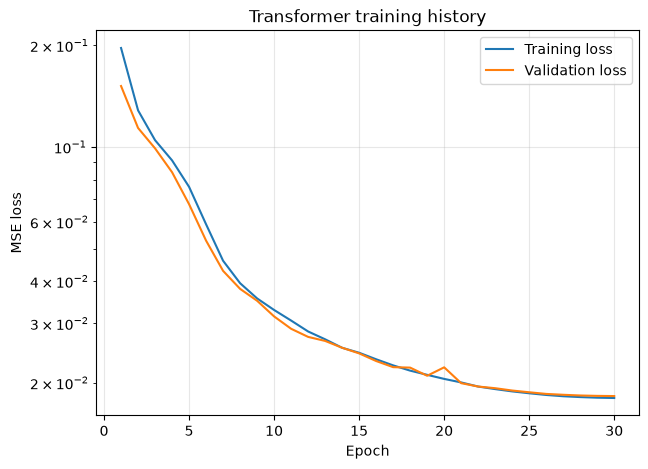

In [55]:
epochs = np.arange(
    1,
    len(transformer_train_losses) + 1,
)

plt.figure(figsize=(7, 5))

plt.plot(
    epochs,
    transformer_train_losses,
    label="Training loss",
)

plt.plot(
    epochs,
    transformer_val_losses,
    label="Validation loss",
)

plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Transformer training history")
plt.yscale("log")
plt.grid(alpha=0.3)
plt.legend()

plt.show()

### Evaluating the Transformer

The Transformer uses the same one-step and rollout utilities as the U-Net. Shared evaluation code prevents preprocessing or metric differences from being mistaken for model differences.

In [56]:
transformer_test_results = (
    evaluate_one_step(
        model=transformer,
        loader=test_loader,
        mean=omega_mean,
        std=omega_std,
        device=device,
    )
)

print(
    "Transformer one-step test results"
)

print(
    "---------------------------------"
)

for metric, value in (
    transformer_test_results.items()
):
    print(
        f"{metric:12s}: "
        f"{value:.6e}"
    )

Transformer one-step test results
---------------------------------
MSE         : 2.375252e-02
Relative L2 : 1.014822e-01


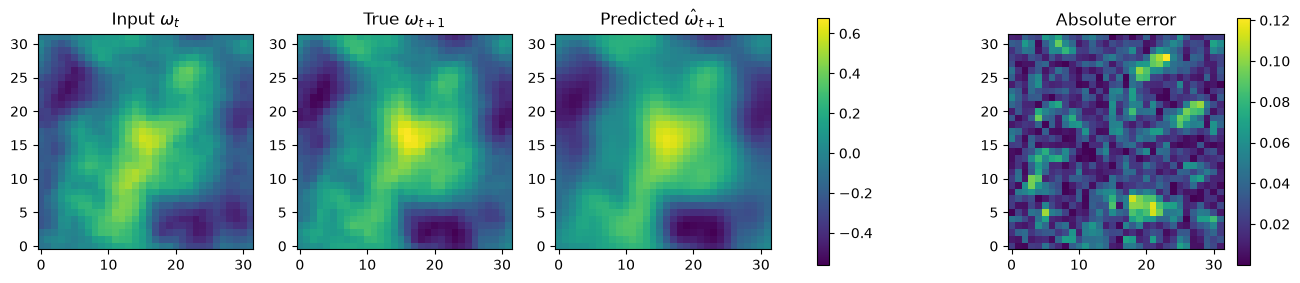

In [57]:
plot_one_step_prediction(
    model=transformer,
    dataset=test_dataset,
    sample_idx=0,
    mean=omega_mean,
    std=omega_std,
    device=device,
)

In [58]:
(transformer_rollout_errors, transformer_teacher_forcing_errors) = (
    evaluate_rollouts(
        model=transformer,
        trajectory_indices=test_indices,
        initial_vorticity=initial_vorticity,
        vorticity=vorticity,
        spatial_stride=SPATIAL_STRIDE,
        mean=omega_mean,
        std=omega_std,
        device=device,
        n_steps=20,
    )
)

print("Autoregressive errors:", transformer_rollout_errors.shape)
print("Teacher-forced errors:", transformer_teacher_forcing_errors.shape)

Autoregressive errors: (200, 21)
Teacher-forced errors: (200, 21)


In [59]:
trajectory_idx = test_indices[1]

true_trajectory = get_trajectory(
    trajectory_idx=trajectory_idx,
    initial_vorticity=initial_vorticity,
    vorticity=vorticity,
    spatial_stride=SPATIAL_STRIDE,
)

pred_trajectory = rollout_model(
    model=transformer,
    initial_state=true_trajectory[0],
    n_steps=20,
    mean=omega_mean,
    std=omega_std,
    device=device,
)

teacher_forced_predictions = rollout_model_teacher_forcing(
        model=transformer,
        true_trajectory=true_trajectory,
        mean=omega_mean,
        std=omega_std,
        device=device,
    )


print(
    "True trajectory:",
    true_trajectory.shape,
)

print(
    "Predicted trajectory:",
    pred_trajectory.shape,
)


print(
    "Predicted teacher forcing trajectory:",
    teacher_forced_predictions.shape,
)

True trajectory: (21, 32, 32)
Predicted trajectory: (21, 32, 32)
Predicted teacher forcing trajectory: (21, 32, 32)


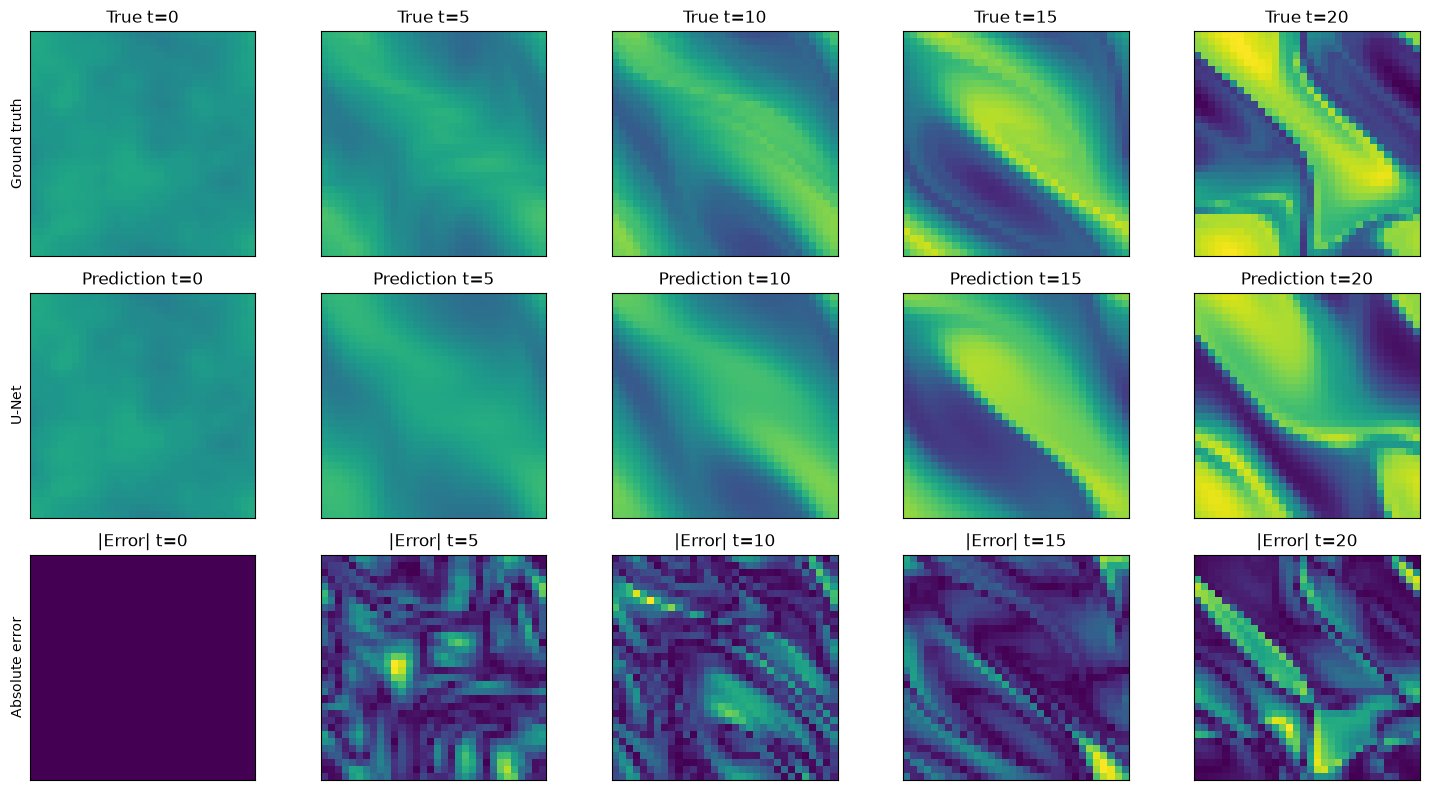

In [60]:
plot_rollout(
    true_trajectory,
    pred_trajectory,
)

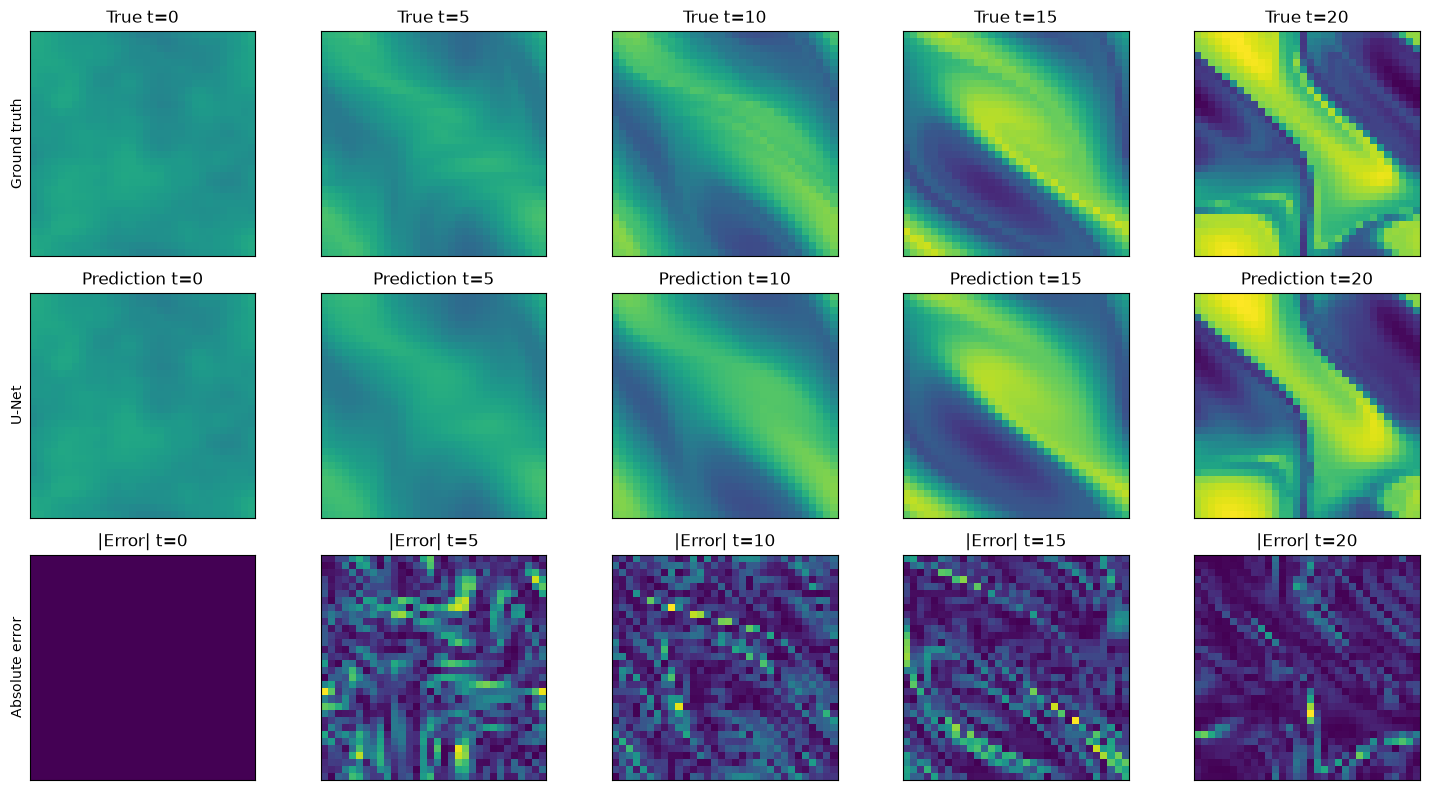

In [61]:
plot_rollout(
    true_trajectory,
    teacher_forced_predictions,
)

## 8. Assignment: Faster attention with learned physics slices

The standard Transformer applies attention directly between all grid points. Our $32\times32$ field contains $N=1024$ point tokens, so every attention head constructs a $1024\times1024$ matrix. The cost grows quadratically with the number of grid points.

We adapt the main idea of [Transolver](https://arxiv.org/abs/2402.02366): first summarize the 1024 point tokens using only $M=64$ learned **physics-slice tokens**, apply attention between these summaries, and then send the resulting information back to all 1024 points.

> The model does **not** select 64 of the original grid points. Each slice token is a learned weighted average of all 1024 point tokens.

The complete information flow is

$$1024\text{ point tokens}\;\longrightarrow\;64\text{ learned summaries}\;\longrightarrow\;\text{attention}\;\longrightarrow\;1024\text{ updated point tokens}.$$

### Notation and tensor shapes

Let:

- $B$ be the batch size;
- $N=H\times W=1024$ be the number of grid points;
- $d=64$ be the token dimension;
- $h=4$ be the number of attention heads;
- $d_h=d/h=16$ be the feature dimension of one head; and
- $M=64$ be the number of learned slices.

The input to one slice-attention layer has shape

$$X\in\mathbb{R}^{B\times N\times d}.$$

### Step 1: split the point features into attention heads

First, apply a learned linear projection to the point features and reshape the result:

$$X\longrightarrow V\in\mathbb{R}^{B\times N\times h\times d_h}.$$

Thus, every grid point has a separate feature vector for every attention head.

### Step 2: give every point a soft membership in the slices

For each point and each head, project its $d_h$ features to $M$ slice scores. Apply softmax over the slice dimension:

$$W_{b,i,r,:}=\operatorname{softmax}(\operatorname{Project}(V_{b,i,r,:})),$$

where $i$ identifies a point and $r$ identifies an attention head. The resulting tensor has shape

$$W\in\mathbb{R}^{B\times N\times h\times M}.$$

Because softmax is applied across the $M$ slices, the memberships of one point sum to one:

$$\sum_{j=1}^{M}W_{b,i,r,j}=1.$$

For example, a point could belong 70% to slice 3, 20% to slice 17, and 10% to slice 42. These memberships are learned from the point features and can therefore change with the input field.

### Step 3: summarize the points into 64 slice tokens

For every head and slice, compute a weighted average of the point features:

$$Z_{b,r,j}=\frac{\sum_{i=1}^{N}W_{b,i,r,j}V_{b,i,r}}{\sum_{i=1}^{N}W_{b,i,r,j}+\varepsilon}.$$

The denominator is the total membership, or *mass*, of the slice. Dividing by it produces an average rather than a sum and avoids making heavily populated slices artificially large. A small $\varepsilon$ prevents division by zero.

The result has shape

$$Z\in\mathbb{R}^{B\times h\times M\times d_h}.$$

After concatenating the head dimensions, it becomes $[B,M,d]$. We have now compressed 1024 point tokens into 64 summary tokens. Spatially distant points may contribute to the same summary if the model gives them similar memberships.

### Step 4: apply ordinary attention to the 64 summaries

Apply standard multi-head self-attention to the slice tokens:

$$Q=ZW_Q,\qquad K=ZW_K,\qquad V_Z=ZW_V,$$

$$Z'=\operatorname{softmax}\left(\frac{QK^\top}{\sqrt{d_h}}\right)V_Z.$$

This attention matrix is only $64\times64$, rather than $1024\times1024$. The slice summaries exchange global information on behalf of the original grid points.

### Step 5: send the updated information back to all points

Reshape the updated slices back into heads and reuse the original memberships to reconstruct a feature for every point:

$$Y_{b,i,r}=\sum_{j=1}^{M}W_{b,i,r,j}Z'_{b,r,j}.$$

If a point belonged 70% to slice 3, 20% to slice 17, and 10% to slice 42, it receives the same mixture of the three updated slice representations. Concatenate the heads and apply an output projection to obtain

$$Y\in\mathbb{R}^{B\times N\times d}.$$

The layer therefore has the same input and output shape as standard self-attention and can replace it inside a Transformer block.

### Step 6: use the result in a Transformer block

As in the previous Transformer, we use layer normalization, residual connections, and a point-wise feed-forward network:

$$\widetilde X=X+\operatorname{SliceAttention}(\operatorname{LayerNorm}(X)),$$

$$X_{\mathrm{next}}=\widetilde X+\operatorname{MLP}(\operatorname{LayerNorm}(\widetilde X)).$$

After several blocks, a final linear layer converts every point feature into a scalar vorticity increment. The model predicts the next state residually:

$$\widehat{\omega}_{t+1}=\omega_t+\Delta\omega_\theta(\omega_t).$$

### Why this can be faster

Full point-wise attention costs approximately

$$\mathcal{O}(N^2d).$$

Slice attention requires point-to-slice aggregation, attention between slices, and slice-to-point reconstruction:

$$\mathcal{O}(NMd+M^2d).$$

For $N=1024$ and $M=64$, the notebook's simplified interaction count is reduced by about

$$\frac{N^2}{NM+M^2}\approx15.$$

This does not guarantee a $15\times$ wall-clock speedup: projections, aggregation, memory movement, and optimized GPU kernels also contribute to runtime. We therefore measure actual forward-pass time later.

### The accuracy–speed trade-off

The number of slices $M$ is the central hyperparameter:

- fewer slices give stronger compression and potentially higher speed, but may discard useful detail;
- more slices preserve more distinct physical states, but increase computation;
- setting $M=N$ largely removes the intended compression benefit.

<!-- > This is a teaching-oriented adaptation of Transolver, not an exact reproduction. It retains the paper's central slice–attend–deslice idea while using the periodic coordinates and one-step regression setup already developed in this notebook. -->
### Assignment

Your task is to implement exactly these three classes in the next two code cells:

1. `PhysicsSliceAttention` — point-to-slice assignment, slice attention, and slice-to-point reconstruction;
2. `PhysicsSliceBlock` — a pre-normalized residual attention/MLP block; and
3. `PhysicsSliceTransformer` — the complete one-step vorticity predictor.

Do not change their constructor arguments or the surrounding training and evaluation code. Use the equations and tensor shapes below as the specification, then complete the `__init__` and `forward` methods of each class. A correct implementation must preserve the requested shapes, remain differentiable, and run the later model-construction, training, timing, and rollout cells without modification.


In [62]:
class PhysicsSliceAttention(nn.Module):
    """
    Compress N point tokens into M learned slice tokens, apply attention
    between slices, and map the result back to the original points.

    The soft assignments should be learned independently by each attention head.

    Args:
        d_model: Feature dimension of each point or slice token.
        n_heads: Number of attention heads. Must divide d_model evenly.
        n_slices: Number of learned slices used to summarize the points.
        dropout: Dropout probability for slice-level attention.
    """

    EPS = 1e-6

    def __init__(
        self,
        d_model,
        n_heads=4,
        n_slices=64,
        dropout=0.0,
    ):
        super().__init__()

        # TODO: Define the dimensions, learned slice assignments, value
        # projection, slice-level self-attention, and output projection.
        # Use a separate slice projection for every attention head:
        #   slice_projection: [n_heads, head_dim, n_slices]
        #   slice_bias:       [n_heads, n_slices]
        # raise NotImplementedError("Complete PhysicsSliceAttention.__init__")

        self._d_model = d_model
        self._n_heads = n_heads
        assert d_model % n_heads == 0, "n_heads must divide d_model"
        self._d_h = d_model // n_heads
        self._n_slices = n_slices
        self._dropout = dropout

        # Slice
        self.val_proj = nn.Sequential(
            nn.Linear(d_model, d_model),  # [B, N, D] -> [B, N, D]
            nn.Unflatten(-1, (n_heads, self._d_h)),  # [B, N, D] -> [B, N, H, D_h]
        )
        self.slice_proj = nn.Parameter(torch.empty(n_heads, self._d_h, n_slices))  # [H, D_h, M]
        self.slice_bias = nn.Parameter(torch.zeros(n_heads, n_slices))  # [H, M]
        nn.init.normal_(self.slice_proj, std=self._d_h**-0.5)

        # Attn
        self.attn = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=n_heads,
            dropout=dropout,
            batch_first=True,
        )

        # Deslice
        self.deslice_proj = nn.Linear(d_model, d_model)

    def forward(self, x):
        # Slice
        v = self.val_proj(x)  # [B, N, D] -> [B, N, H, D_h]
        w = F.softmax(torch.einsum("birk,rkj->birj", v, self.slice_proj) + self.slice_bias, dim=-1)  # [B, N, H, M]
        z = torch.einsum("birj,birk->brjk", w, v) / (w.sum(dim=1).unsqueeze(-1) + self.EPS)  # [B, H, M, D_h]
        z = z.permute(0, 2, 1, 3).flatten(-2)  # [B, H, M, D_h] -> [B, M, D]

        # Attn
        z = self.attn(z, z, z, need_weights=False)[0]  # [B, M, D] -> [B, M, D]

        # Deslice
        z = z.unflatten(-1, (self._n_heads, self._d_h))  # [B, M, D] -> [B, M, H, D_h]
        z = torch.einsum("birj,bjrk->birk", w, z)  # [B, N, H, D_h]
        x = self.deslice_proj(z.flatten(-2))  # [B, N, H, D_h] -> [B, N, D]

        return x  # [B, N, D]

In [63]:
class PhysicsSliceBlock(nn.Module):
    """
    Pre-normalized slice-attention and feed-forward residual block.

    Args:
        d_model: Feature dimension of every token.
        n_heads: Number of heads in the slice-attention module.
        n_slices: Number of learned slice tokens.
        dim_feedforward: Hidden dimension of the point-wise MLP.
        dropout: Dropout probability used in attention and the MLP.
    """

    def __init__(
        self,
        d_model,
        n_heads,
        n_slices,
        dim_feedforward,
        dropout=0.0,
    ):
        super().__init__()

        self._d_model = d_model
        self._n_heads = n_heads
        assert d_model % n_heads == 0, "n_heads must divide d_model"
        self._d_h = d_model // n_heads
        self._n_slices = n_slices
        self._d_forward = dim_feedforward
        self._dropout = dropout

        # Attn
        self.norm_attn = nn.LayerNorm(d_model)
        self.slice_attn = PhysicsSliceAttention(
            d_model=d_model,
            n_heads=n_heads,
            n_slices=n_slices,
            dropout=dropout,
        )

        # MLP
        self.norm_forward = nn.LayerNorm(d_model)
        self.mlp = nn.Sequential(
            nn.Linear(d_model, dim_feedforward),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim_feedforward, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        # Attn
        x = x + self.slice_attn(self.norm_attn(x))  # [B, N, D]

        # MLP
        x = x + self.mlp(self.norm_forward(x))  # [B, N, D]

        return x  # [B, N, D]


class PhysicsSliceTransformer(nn.Module):
    """
    One-step vorticity predictor using learned slice attention.

    Args:
        H: Height of the input spatial grid.
        W: Width of the input spatial grid.
        d_model: Feature dimension of every token.
        n_heads: Number of attention heads in each slice block.
        n_layers: Number of consecutive PhysicsSliceBlock layers.
        n_slices: Number of learned slice tokens in each block.
        dim_feedforward: Hidden dimension of each block's MLP.
        dropout: Dropout probability used inside the blocks.
        residual_prediction: If True, add the predicted increment to the
            input field; otherwise return the increment alone.
    """

    def __init__(
        self,
        H,
        W,
        d_model=64,
        n_heads=4,
        n_layers=2,
        n_slices=64,
        dim_feedforward=128,
        dropout=0.0,
        residual_prediction=True,
    ):
        super().__init__()

        self._H = H
        self._W = W
        self._d_model = d_model
        self._n_heads = n_heads
        self._n_layers = n_layers
        self._n_slices = n_slices
        self._d_forward = dim_feedforward
        self._dropout = dropout
        self._residual_prediction = residual_prediction

        # Embedding
        self.register_buffer("pos_emb", make_periodic_position_features(H, W))  # [N, pos_feat]
        self.input_proj = nn.Linear(self.pos_emb.shape[-1] + 1, d_model)

        # Blocks
        self.blocks = nn.ModuleList([
            PhysicsSliceBlock(
                d_model=d_model,
                n_heads=n_heads,
                n_slices=n_slices,
                dim_feedforward=dim_feedforward,
                dropout=dropout,
            ) for _ in range(n_layers)
        ])

        # Output projection
        self.out_proj = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, 1),  # [B, N, D] -> [B, N, 1]
            nn.Flatten(-2),  # [B, N, 1] -> [B, N]
            nn.Unflatten(-1, (1, H, W))  # [B, N] -> [B, 1, H, W]
        )

    def forward(self, x):
        res = self.input_proj(
            torch.cat((
                x.flatten(1).unsqueeze(-1),  # [B, 1, H, W] -> [B, N, 1]
                self.pos_emb.unsqueeze(0).expand(x.shape[0], -1, -1),  # [N, pos_feat] -> [B, N, pos_feat]
            ), dim=-1)
        )  # [B, 1, H, W] -> [B, N, D]
        for block in self.blocks:
            res = block(res)  # [B, N, D] -> [B, N, D]
        res = self.out_proj(res)  # [B, N, D] -> [B, 1, H, W]

        if self._residual_prediction:
            return x + res  # [B, 1, H, W]
        return res  # [B, 1, H, W]

In [64]:
N_SLICES = 64

slice_transformer = PhysicsSliceTransformer(
    H=H,
    W=W,
    d_model=64,
    n_heads=4,
    n_layers=2,
    n_slices=N_SLICES,
    dim_feedforward=128,
    dropout=0.0,
    residual_prediction=True,
).to(device)
slice_transformer.compile()

slice_n_params = sum(
    p.numel() for p in slice_transformer.parameters() if p.requires_grad
)

full_interactions = (H * W) ** 2
slice_interactions = (H * W) * N_SLICES + N_SLICES ** 2

print(f"Physics-slice Transformer parameters: {slice_n_params:,}")
print(f"Grid tokens: {H * W}; learned slices: {N_SLICES}")
print(
    "Interaction-count reduction: "
    f"{full_interactions / slice_interactions:.1f}x"
)

Physics-slice Transformer parameters: 92,865
Grid tokens: 1024; learned slices: 64
Interaction-count reduction: 15.1x


### Training

For a direct classroom comparison, this model uses the same optimizer settings and number of epochs as the full Transformer. The number of slices is the main efficiency–accuracy control: increasing it preserves more detail but increases both slicing and attention cost.

In [65]:
slice_criterion = nn.MSELoss()
slice_optimizer = torch.optim.AdamW(
    slice_transformer.parameters(),
    lr=1e-3,
    weight_decay=1e-4,
)

N_SLICE_EPOCHS = N_TRANSFORMER_EPOCHS

slice_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    slice_optimizer,
    T_max=N_SLICE_EPOCHS,
)

In [66]:
slice_train_losses = []
slice_val_losses = []
best_slice_val_loss = float("inf")
best_slice_state = None

start_time = time.time()

for epoch in range(1, N_SLICE_EPOCHS + 1):
    train_loss = train_one_epoch(
        model=slice_transformer,
        loader=train_loader,
        optimizer=slice_optimizer,
        criterion=slice_criterion,
        device=device,
    )

    val_loss = evaluate_loss(
        model=slice_transformer,
        loader=val_loader,
        criterion=slice_criterion,
        device=device,
    )

    slice_train_losses.append(train_loss)
    slice_val_losses.append(val_loss)

    if val_loss < best_slice_val_loss:
        best_slice_val_loss = val_loss
        best_slice_state = copy.deepcopy(
            slice_transformer.state_dict()
        )

    print(
        f"Epoch {epoch:3d}/{N_SLICE_EPOCHS} | "
        f"Train: {train_loss:.6e} | "
        f"Val: {val_loss:.6e} | "
        f"LR: {slice_optimizer.param_groups[0]['lr']:.2e}"
    )

    slice_scheduler.step()


elapsed = time.time() - start_time

slice_transformer.load_state_dict(best_slice_state)
slice_transformer.eval()

print(f"Training time: {elapsed / 60:.1f} minutes")
print(f"Best validation loss: {best_slice_val_loss:.6e}")

Epoch   1/30 | Train: 2.017770e-01 | Val: 1.787599e-01 | LR: 1.00e-03
Epoch   2/30 | Train: 1.747710e-01 | Val: 1.639776e-01 | LR: 9.97e-04
Epoch   3/30 | Train: 1.397831e-01 | Val: 1.217791e-01 | LR: 9.89e-04
Epoch   4/30 | Train: 1.125716e-01 | Val: 1.076128e-01 | LR: 9.76e-04
Epoch   5/30 | Train: 1.002963e-01 | Val: 9.638533e-02 | LR: 9.57e-04
Epoch   6/30 | Train: 9.200309e-02 | Val: 9.018614e-02 | LR: 9.33e-04
Epoch   7/30 | Train: 8.596801e-02 | Val: 8.377275e-02 | LR: 9.05e-04
Epoch   8/30 | Train: 7.984442e-02 | Val: 7.975251e-02 | LR: 8.72e-04
Epoch   9/30 | Train: 7.515030e-02 | Val: 7.396548e-02 | LR: 8.35e-04
Epoch  10/30 | Train: 7.169889e-02 | Val: 7.076963e-02 | LR: 7.94e-04
Epoch  11/30 | Train: 6.800455e-02 | Val: 6.734049e-02 | LR: 7.50e-04
Epoch  12/30 | Train: 6.515777e-02 | Val: 6.514885e-02 | LR: 7.03e-04
Epoch  13/30 | Train: 6.342755e-02 | Val: 6.390375e-02 | LR: 6.55e-04
Epoch  14/30 | Train: 6.132359e-02 | Val: 6.150546e-02 | LR: 6.04e-04
Epoch  15/30 | Train

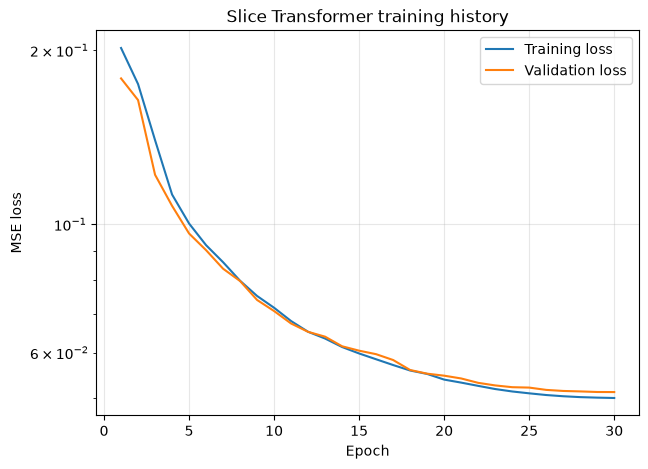

In [67]:
epochs = np.arange(
    1,
    len(slice_train_losses) + 1,
)

plt.figure(figsize=(7, 5))

plt.plot(
    epochs,
    slice_train_losses,
    label="Training loss",
)

plt.plot(
    epochs,
    slice_val_losses,
    label="Validation loss",
)

plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Slice Transformer training history")
plt.yscale("log")
plt.grid(alpha=0.3)
plt.legend()

plt.show()

### Measuring actual speed

Asymptotic complexity is not the same as wall-clock speed. Small tensor operations, kernel-launch overhead, and optimized PyTorch attention kernels all matter. We therefore time complete forward passes after a warm-up. Run this benchmark on the same device and with the same batch for both models.

In [68]:
@torch.no_grad()
def benchmark_forward_pass(
    model,
    inputs,
    n_warmup=10,
    n_repeats=50,
):
    """Return average forward-pass time in milliseconds."""
    model.eval()

    for _ in range(n_warmup):
        model(inputs)

    if inputs.is_cuda:
        torch.cuda.synchronize()

    start = time.perf_counter()

    for _ in range(n_repeats):
        model(inputs)

    if inputs.is_cuda:
        torch.cuda.synchronize()

    elapsed = time.perf_counter() - start
    return 1000 * elapsed / n_repeats


timing_batch = x_batch.to(device).float()

full_transformer_ms = benchmark_forward_pass(
    transformer, timing_batch
)
slice_transformer_ms = benchmark_forward_pass(
    slice_transformer, timing_batch
)

print(f"Full Transformer:  {full_transformer_ms:.3f} ms/batch")
print(f"Slice Transformer: {slice_transformer_ms:.3f} ms/batch")
print(
    "Measured speedup:    "
    f"{full_transformer_ms / slice_transformer_ms:.2f}x"
)

Full Transformer:  22.685 ms/batch
Slice Transformer: 5.560 ms/batch
Measured speedup:    4.08x


### Accuracy and rollout evaluation

Speed is useful only if the compressed model remains accurate. We apply the same physical-unit metrics and autoregressive rollout test used above. Compare both one-step error and the shape of the rollout error curve.

In [69]:
slice_test_results = evaluate_one_step(
    model=slice_transformer,
    loader=test_loader,
    mean=omega_mean,
    std=omega_std,
    device=device,
)

print("Physics-slice Transformer one-step test results")
print("------------------------------------------------")
for metric, value in slice_test_results.items():
    print(f"{metric:12s}: {value:.6e}")

Physics-slice Transformer one-step test results
------------------------------------------------
MSE         : 6.583752e-02
Relative L2 : 1.730571e-01


In [70]:
(
    slice_rollout_errors,
    slice_teacher_forcing_errors,
) = evaluate_rollouts(
    model=slice_transformer,
    trajectory_indices=test_indices,
    initial_vorticity=initial_vorticity,
    vorticity=vorticity,
    spatial_stride=SPATIAL_STRIDE,
    mean=omega_mean,
    std=omega_std,
    device=device,
    n_steps=20,
)

print("Autoregressive errors:", slice_rollout_errors.shape)
print("Teacher-forced errors:", slice_teacher_forcing_errors.shape)

Autoregressive errors: (200, 21)
Teacher-forced errors: (200, 21)


In [71]:
trajectory_idx = test_indices[1]

true_trajectory = get_trajectory(
    trajectory_idx=trajectory_idx,
    initial_vorticity=initial_vorticity,
    vorticity=vorticity,
    spatial_stride=SPATIAL_STRIDE,
)

pred_trajectory = rollout_model(
    model=slice_transformer,
    initial_state=true_trajectory[0],
    n_steps=20,
    mean=omega_mean,
    std=omega_std,
    device=device,
)

teacher_forced_predictions = rollout_model_teacher_forcing(
        model=slice_transformer,
        true_trajectory=true_trajectory,
        mean=omega_mean,
        std=omega_std,
        device=device,
    )


print(
    "True trajectory:",
    true_trajectory.shape,
)

print(
    "Predicted trajectory:",
    pred_trajectory.shape,
)


print(
    "Predicted teacher forcing trajectory:",
    teacher_forced_predictions.shape,
)

True trajectory: (21, 32, 32)
Predicted trajectory: (21, 32, 32)
Predicted teacher forcing trajectory: (21, 32, 32)


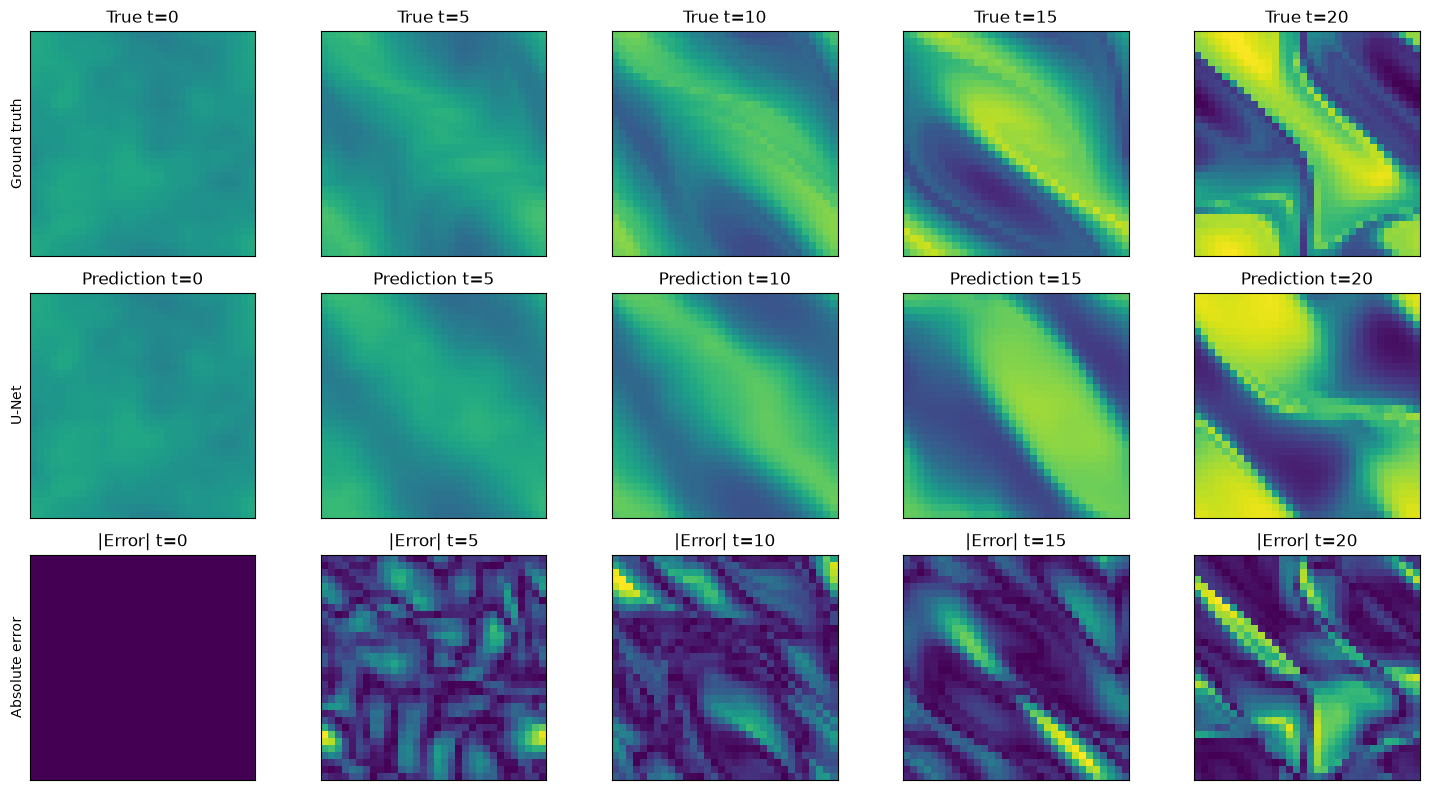

In [72]:
plot_rollout(
    true_trajectory,
    pred_trajectory,
)

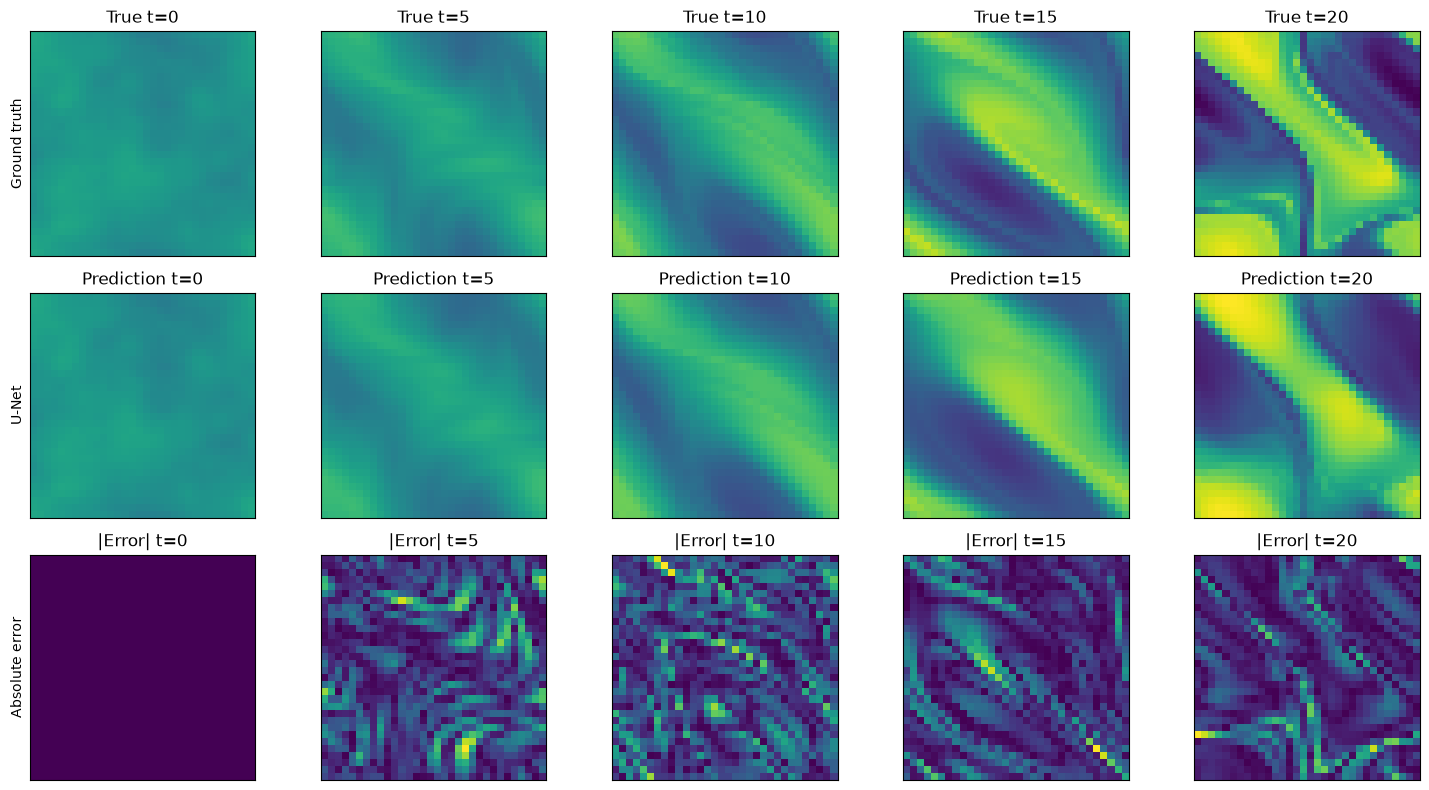

In [73]:
plot_rollout(
    true_trajectory,
    teacher_forced_predictions,
)

## 9. Model comparison and discussion

The final cells compare one-step metrics and error growth over time. 

In [74]:
print(
    f"{'Model':15s} "
    f"{'MSE':>14s} "
    f"{'Relative L2':>14s}"
)

print("-" * 46)


print(
    f"{'U-Net':15s} "
    f"{unet_test_results['MSE']:14.6e} "
    f"{unet_test_results['Relative L2']:14.6e}"
)

print(
    f"{'Transformer':15s} "
    f"{transformer_test_results['MSE']:14.6e} "
    f"{transformer_test_results['Relative L2']:14.6e}"
)

print(
    f"{'Physics-slice':15s} "
    f"{slice_test_results['MSE']:14.6e} "
    f"{slice_test_results['Relative L2']:14.6e}"
)

Model                      MSE    Relative L2
----------------------------------------------
U-Net             2.644214e-02   1.353959e-01
Transformer       2.375252e-02   1.014822e-01
Physics-slice     6.583752e-02   1.730571e-01


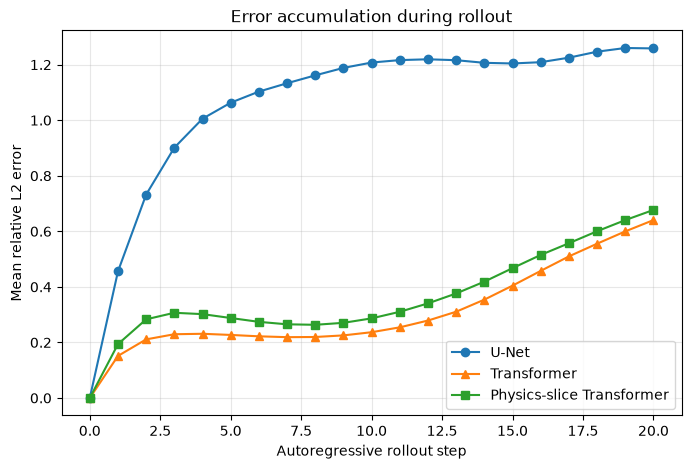

In [75]:
unet_mean = (
    unet_rollout_errors.mean(
        axis=0
    )
)

transformer_mean = (
    transformer_rollout_errors.mean(
        axis=0
    )
)

slice_mean = (
    slice_rollout_errors.mean(
        axis=0
    )
)


steps = np.arange(
    len(transformer_mean)
)

plt.figure(figsize=(8, 5))


plt.plot(
    steps,
    unet_mean,
    marker="o",
    label="U-Net",
)

plt.plot(
    steps,
    transformer_mean,
    marker="^",
    label="Transformer",
)

plt.plot(
    steps,
    slice_mean,
    marker="s",
    label="Physics-slice Transformer",
)

plt.xlabel(
    "Autoregressive rollout step"
)

plt.ylabel(
    "Mean relative L2 error"
)

plt.title(
    "Error accumulation during rollout"
)

plt.grid(alpha=0.3)
plt.legend()

plt.show()

## 10. Assignment: Pushforward training for the Slice Transformer

In Section 8, you trained the physics-slice Transformer with ordinary one-step supervision. In this assignment, you will design and implement pushforward training for the same model. Pushforward training should expose the model to states produced by its own autoregressive predictions before applying the supervised loss.

### Tasks

- Implement a dataset class that supplies the trajectory information needed for pushforward training and supports the changing rollout horizon required by your scheduler.
- Implement the pushforward training procedure, including a one-epoch training function. Your implementation must perform the scheduled preliminary model steps without gradient tracking and apply the loss to the subsequent differentiable prediction.
- Design and implement a scheduler for the number of pushforward steps used during training. Explain your scheduling choice.
- Instantiate and train a new `PhysicsSliceTransformer` with the same architecture and model-size hyperparameters used in Section 8. Add any other code required for training, validation, checkpoint selection, and reproducibility.
- Plot the training and validation loss curves.
- Evaluate the trained model on the test set for both one-step prediction and autoregressive rollout, using the same metrics and evaluation conventions as in the previous sections.
- Compare the pushforward-trained model with the ordinarily trained physics-slice Transformer from Section 8. Discuss both one-step accuracy and how the relative L2 error develops over the rollout.

### Expected output

Your completed section should contain the dataset, scheduler, training and validation logic, a trained pushforward model, loss curves, one-step test metrics, rollout-error results, comparison plots, and a short interpretation of the results. The design of the dataset, scheduler, and training procedure is part of the assignment; no implementation template is provided.

In [93]:
MAX_PUSHFORWARD_STEPS = 5
ONE_STEP_BATCH_FRACTION = 0.25
FRONTIER_BATCH_FRACTION = 0.5

In [94]:
class NavierStokesPushforwardDataset(Dataset):
    """Supplies normalized start-target pairs for pushforward training.

    Args:
        initial_vorticity: initial states, shape [trajectories, height, width]
        vorticity: future states, shape [trajectories, height, width, time]
        trajectory_indices: global trajectory indices included in this split
        mean: training-set normalization mean
        std: training-set normalization std
        spatial_stride: spatial stride
    """

    def __init__(
        self,
        initial_vorticity: np.ndarray,
        vorticity: np.ndarray,
        trajectory_indices: np.ndarray,
        mean: float,
        std: float,
        spatial_stride: int = 1,
    ) -> None:
        trajectory_indices = np.asarray(trajectory_indices, dtype=np.int64)
        assert trajectory_indices.size != 0, "trajectory_indices must not be empty"
        assert spatial_stride >= 1, "spatial_stride must be positive"
        assert std > 0.0, "std must be positive"

        height = (initial_vorticity.shape[1] + spatial_stride - 1) // (spatial_stride)
        width = (initial_vorticity.shape[2] + spatial_stride - 1) // (spatial_stride)
        n_states = vorticity.shape[-1] + 1
        states = np.empty(
            (trajectory_indices.size, n_states, height, width),
            dtype=np.float32,
        )
        states[:, 0] = initial_vorticity[
            trajectory_indices,
            ::spatial_stride,
            ::spatial_stride,
        ]
        states[:, 1:] = np.moveaxis(
            vorticity[
                trajectory_indices,
                ::spatial_stride,
                ::spatial_stride,
                :,
            ],
            -1,
            1,
        )
        states -= np.float32(mean)
        states /= np.float32(std)

        self.states = torch.from_numpy(states).unsqueeze(2)
        self.n_trajectories = self.states.shape[0]
        self.n_states = self.states.shape[1]
        self.n_transitions = self.n_states - 1

    def __len__(self) -> int:
        """Returns the one-step-equivalent number of samples per epoch."""
        return self.n_trajectories * self.n_transitions

    def __getitem__(
        self,
        index: tuple[int, int, int],
    ) -> tuple[torch.Tensor, torch.Tensor, int]:
        """Loads one pushforward start-target pair.

        Args:
            index: (trajectory_position, start_time, horizon). The target time is start_time + horizon + 1

        Returns:
            Start and target tensors with shape [1, height, width] and dtype
            float32, followed by the integer pushforward horizon.
        """
        trajectory_position, start_time, horizon = index
        target_time = start_time + horizon + 1

        assert 0 <= trajectory_position < self.n_trajectories, "trajectory_position is out of range"
        assert start_time >= 0 and target_time < self.n_states, "pushforward time range is out of bounds"

        return (
            self.states[trajectory_position, start_time],
            self.states[trajectory_position, target_time],
            horizon,
        )

In [95]:
def pushforward_horizon_probabilities(max_horizon: int) -> torch.Tensor:
    """Returns the batch-horizon distribution for one curriculum stage.

    Args:
        max_horizon: largest currently permitted pushforward horizon

    Returns:
        Float64 probabilities with shape [max_horizon + 1]
    """
    assert max_horizon >= 0, "max_horizon must be non-negative"
    if max_horizon == 0:
        return torch.ones(1, dtype=torch.float64)

    probs = torch.zeros(max_horizon + 1, dtype=torch.float64)
    probs[0] = ONE_STEP_BATCH_FRACTION

    if max_horizon == 1:
        probs[1] = 1.0 - ONE_STEP_BATCH_FRACTION
        return probs

    probs[-1] = FRONTIER_BATCH_FRACTION
    rest = (
        1.0 - ONE_STEP_BATCH_FRACTION - FRONTIER_BATCH_FRACTION
    )
    probs[1:-1] = rest / (max_horizon - 1)
    return probs

In [96]:
class PushforwardBatchSampler:
    """Builds homogeneous-horizon batches without materializing windows.

    Each epoch has the same number of samples as ordinary one-step training.
    Candidate start times are shuffled without replacement for each horizon;
    a pool is reshuffled iff an epoch requests more samples than that
    horizon has unique start-target pairs.

    Args:
        dataset: pushforward dataset indexed by sample specifications
        batch_size: number of samples per batch
        seed: base seed used for deterministic epoch sampling
        drop_last: whether to discard the final incomplete batch
    """

    def __init__(
        self,
        dataset: NavierStokesPushforwardDataset,
        batch_size: int,
        seed: int,
        drop_last: bool = False,
    ) -> None:
        assert batch_size >= 1, "batch_size must be positive"

        self.dataset = dataset
        self.batch_size = batch_size
        self.seed = seed
        self.drop_last = drop_last
        self.epoch = 0
        self.max_horizon = 0

    def set_epoch(self, epoch: int, max_horizon: int) -> None:
        """Sets deterministic sampling state for the next epoch.

        Args:
            epoch: one-based training epoch
            max_horizon: largest permitted preliminary rollout length
        """
        assert epoch >= 1, "epoch must be one-based and positive"
        assert 0 <= max_horizon < self.dataset.n_states - 1, "max_horizon does not fit in a trajectory"

        self.epoch = epoch
        self.max_horizon = max_horizon

    def __len__(self) -> int:
        """Returns the number of batches in one epoch."""
        if self.drop_last:
            return len(self.dataset) // self.batch_size
        return (len(self.dataset) + self.batch_size - 1) // self.batch_size

    def _batch_horizons(self, generator: torch.Generator) -> torch.Tensor:
        """Allocates exact batch counts according to the horizon mixture."""
        expected_counts = pushforward_horizon_probabilities(self.max_horizon) * len(self)
        counts = torch.floor(expected_counts).to(torch.int64)
        remainder = len(self) - int(counts.sum())

        if remainder > 0:
            fractional_counts = expected_counts - counts
            indices = torch.argsort(fractional_counts, descending=True)
            counts[indices[:remainder]] += 1

        horizons = torch.repeat_interleave(
            torch.arange(self.max_horizon + 1),
            counts,
        )
        permutation = torch.randperm(len(horizons), generator=generator)
        return horizons[permutation]

    def __iter__(
        self,
    ) -> collections.abc.Iterator[list[tuple[int, int, int]]]:
        """Yields batches of dataset indices for the configured epoch."""
        generator = torch.Generator().manual_seed(self.seed + self.epoch)
        horizons = self._batch_horizons(generator)
        pools: dict[int, torch.Tensor] = {}
        offsets: dict[int, int] = {}

        samples_remaining = len(self.dataset)
        for horizon_tensor in horizons:
            if self.drop_last:
                current_batch_size = self.batch_size
            else:
                current_batch_size = min(self.batch_size, samples_remaining)

            horizon = int(horizon_tensor)
            n_start_times = self.dataset.n_states - horizon - 1
            pool_size = self.dataset.n_trajectories * n_start_times
            flat_indices = []

            while len(flat_indices) < current_batch_size:
                if horizon not in pools or offsets[horizon] == pool_size:
                    pools[horizon] = torch.randperm(
                        pool_size,
                        generator=generator,
                    )
                    offsets[horizon] = 0

                n_needed = current_batch_size - len(flat_indices)
                n_available = pool_size - offsets[horizon]
                n_selected = min(n_needed, n_available)
                selection = pools[horizon][
                    offsets[horizon] : offsets[horizon] + n_selected
                ]
                flat_indices.extend(selection.tolist())
                offsets[horizon] += n_selected

            yield [
                (
                    flat_index // n_start_times,
                    flat_index % n_start_times,
                    horizon,
                )
                for flat_index in flat_indices
            ]
            samples_remaining -= current_batch_size

In [97]:
def pushforward_horizon(
    epoch: int,
    n_epochs: int,
    max_steps: int = MAX_PUSHFORWARD_STEPS,
    warmup_fraction: float = 0.25,
) -> int:
    """Returns the largest pushforward horizon for a one-based epoch.

    Args:
        epoch: current one-based epoch
        n_epochs: total number of training epochs
        max_steps: maximum number of preliminary no-gradient steps
        warmup_fraction: fraction of epochs reserved for one-step warm-up

    Returns:
        Integer horizon in the inclusive range [0, max_steps]
    """
    assert n_epochs >= 1, "n_epochs must be positive"
    assert 1 <= epoch <= n_epochs, "epoch must lie in [1, n_epochs]"
    assert max_steps >= 0, "max_steps must be non-negative"
    assert 0.0 <= warmup_fraction < 1.0, "warmup_fraction must lie in [0, 1)"

    warmup_epochs = max(1, round(warmup_fraction * n_epochs))

    if epoch <= warmup_epochs or max_steps == 0:
        return 0

    progress = (epoch - warmup_epochs) / max(1, n_epochs - warmup_epochs)
    return min(max_steps, int(np.ceil(progress * max_steps)))

In [98]:
def train_one_epoch_pushforward(
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    criterion: nn.Module,
    device: torch.device,
) -> float:
    """Trains for one epoch using stop-gradient preliminary rollouts.

    Args:
        model: one-step dynamics model
        loader: loader yielding homogeneous-horizon start-target batches
        optimizer: parameter optimizer
        criterion: supervised loss function
        device: training device

    Returns:
        Sample-averaged training loss
    """

    model.train()

    total_loss = 0.0
    n_samples = 0

    for state, target, horizons in loader:
        assert torch.all(horizons == horizons[0]), "each batch must contain exactly one horizon"
        horizon = int(horizons[0])

        state = state.to(
            device=device,
            dtype=torch.float32,
            non_blocking=True,
        )
        target = target.to(
            device=device,
            dtype=torch.float32,
            non_blocking=True,
        )

        if horizon > 0:
            with torch.no_grad():
                for _ in range(horizon):
                    state = model(state)

        pred = model(state)
        loss = criterion(pred, target)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        batch_size = state.shape[0]
        total_loss += loss.item() * batch_size
        n_samples += batch_size

    return total_loss / n_samples

In [99]:
@torch.no_grad()
def evaluate_pushforward_loss(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    device: torch.device,
) -> float:
    """Evaluates loss after deterministic no-gradient pushforward rollouts.

    Args:
        model: one-step dynamics model
        loader: loader yielding homogeneous-horizon start-target batches
        criterion: supervised loss function
        device: evaluation device

    Returns:
        Sample-averaged pushforward loss
    """
    model.eval()
    total_loss = 0.0
    n_samples = 0

    for state, target, horizons in loader:
        assert torch.all(horizons == horizons[0]), "each batch must contain exactly one horizon"
        horizon = int(horizons[0])

        state = state.to(
            device=device,
            dtype=torch.float32,
            non_blocking=True,
        )
        target = target.to(
            device=device,
            dtype=torch.float32,
            non_blocking=True,
        )

        for _ in range(horizon):
            state = model(state)

        pred = model(state)
        loss = criterion(pred, target)
        batch_size = state.shape[0]
        total_loss += loss.item() * batch_size
        n_samples += batch_size

    return total_loss / n_samples

In [100]:
pushforward_train_dataset = NavierStokesPushforwardDataset(
    initial_vorticity=initial_vorticity,
    vorticity=vorticity,
    trajectory_indices=train_indices,
    mean=omega_mean,
    std=omega_std,
    spatial_stride=SPATIAL_STRIDE,
)

pushforward_train_batch_sampler = PushforwardBatchSampler(
    dataset=pushforward_train_dataset,
    batch_size=BATCH_SIZE,
    seed=SEED,
)

pushforward_train_loader = DataLoader(
    pushforward_train_dataset,
    batch_sampler=pushforward_train_batch_sampler,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=True,
)

pushforward_val_dataset = NavierStokesPushforwardDataset(
    initial_vorticity=initial_vorticity,
    vorticity=vorticity,
    trajectory_indices=val_indices,
    mean=omega_mean,
    std=omega_std,
    spatial_stride=SPATIAL_STRIDE,
)

pushforward_val_indices = [
    (trajectory_position, start_time, MAX_PUSHFORWARD_STEPS)
    for trajectory_position in range(pushforward_val_dataset.n_trajectories)
    for start_time in range(
        pushforward_val_dataset.n_states - MAX_PUSHFORWARD_STEPS - 1
    )
]

pushforward_val_loader = DataLoader(
    pushforward_val_dataset,
    batch_size=BATCH_SIZE,
    sampler=pushforward_val_indices,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=True,
)

example_start, example_target, example_horizon = (
    pushforward_train_dataset[(0, 0, MAX_PUSHFORWARD_STEPS)]
)

print("Pushforward samples per epoch:", len(pushforward_train_dataset))
print("Start shape:", tuple(example_start.shape))
print("Target shape:", tuple(example_target.shape))
print("Example horizon:", example_horizon)

Pushforward samples per epoch: 18000
Start shape: (1, 32, 32)
Target shape: (1, 32, 32)
Example horizon: 5


In [101]:
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

pushforward_transformer = PhysicsSliceTransformer(
    H=H,
    W=W,
    d_model=64,
    n_heads=4,
    n_layers=2,
    n_slices=N_SLICES,
    dim_feedforward=128,
    dropout=0.0,
    residual_prediction=True,
).to(device)
pushforward_transformer.compile()

pushforward_criterion = nn.MSELoss()

pushforward_optimizer = torch.optim.AdamW(
    pushforward_transformer.parameters(),
    lr=1e-3,
    weight_decay=1e-4,
)

N_PUSHFORWARD_EPOCHS = N_SLICE_EPOCHS

pushforward_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    pushforward_optimizer,
    T_max=N_PUSHFORWARD_EPOCHS,
)

n_params = sum(
    p.numel()
    for p in pushforward_transformer.parameters()
    if p.requires_grad
)

print(f"Pushforward model parameters: {n_params:,}")

print(
    "Horizon schedule:",
    [
        pushforward_horizon(epoch, N_PUSHFORWARD_EPOCHS)
        for epoch in range(1, N_PUSHFORWARD_EPOCHS + 1)
    ],
)

Pushforward model parameters: 92,865
Horizon schedule: [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 2, 2, 2, 2, 3, 3, 3, 3, 3, 4, 4, 4, 4, 5, 5, 5, 5, 5]


In [102]:
pushforward_train_losses = []
pushforward_val_losses = []
pushforward_one_step_val_losses = []
pushforward_horizons = []

best_pushforward_val_loss = float("inf")
best_pushforward_state = None

start_time = time.time()

for epoch in range(1, N_PUSHFORWARD_EPOCHS + 1):

    max_horizon = pushforward_horizon(
        epoch,
        N_PUSHFORWARD_EPOCHS,
    )
    pushforward_train_batch_sampler.set_epoch(
        epoch=epoch,
        max_horizon=max_horizon,
    )

    train_loss = train_one_epoch_pushforward(
        model=pushforward_transformer,
        loader=pushforward_train_loader,
        optimizer=pushforward_optimizer,
        criterion=pushforward_criterion,
        device=device,
    )

    one_step_val_loss = evaluate_loss(
        model=pushforward_transformer,
        loader=val_loader,
        criterion=pushforward_criterion,
        device=device,
    )
    val_loss = evaluate_pushforward_loss(
        model=pushforward_transformer,
        loader=pushforward_val_loader,
        criterion=pushforward_criterion,
        device=device,
    )

    pushforward_train_losses.append(train_loss)
    pushforward_val_losses.append(val_loss)
    pushforward_one_step_val_losses.append(one_step_val_loss)
    pushforward_horizons.append(max_horizon)

    if val_loss < best_pushforward_val_loss:
        best_pushforward_val_loss = val_loss
        best_pushforward_state = copy.deepcopy(
            pushforward_transformer.state_dict()
        )

    pushforward_scheduler.step()

    print(
        f"Epoch {epoch:3d}/{N_PUSHFORWARD_EPOCHS} | "
        f"k_max: {max_horizon} | "
        f"Train: {train_loss:.6e} | "
        f"Val PF: {val_loss:.6e} | "
        f"Val 1-step: {one_step_val_loss:.6e} | "
        f"LR: {pushforward_optimizer.param_groups[0]['lr']:.2e}"
    )

elapsed = time.time() - start_time

pushforward_transformer.load_state_dict(best_pushforward_state)
pushforward_transformer.eval()

print()
print(f"Training time: {elapsed / 60:.1f} minutes")
print(
    f"Best k={MAX_PUSHFORWARD_STEPS} validation loss: "
    f"{best_pushforward_val_loss:.6e}"
)

Epoch   1/30 | k_max: 0 | Train: 1.936230e-01 | Val PF: 5.708995e-01 | Val 1-step: 1.785207e-01 | LR: 9.97e-04
Epoch   2/30 | k_max: 0 | Train: 1.717927e-01 | Val PF: 4.347123e-01 | Val 1-step: 1.444904e-01 | LR: 9.89e-04
Epoch   3/30 | k_max: 0 | Train: 1.236369e-01 | Val PF: 3.084399e-01 | Val 1-step: 1.140227e-01 | LR: 9.76e-04
Epoch   4/30 | k_max: 0 | Train: 1.046808e-01 | Val PF: 3.013412e-01 | Val 1-step: 9.968204e-02 | LR: 9.57e-04
Epoch   5/30 | k_max: 0 | Train: 9.421278e-02 | Val PF: 3.052014e-01 | Val 1-step: 9.061301e-02 | LR: 9.33e-04
Epoch   6/30 | k_max: 0 | Train: 8.748076e-02 | Val PF: 3.369928e-01 | Val 1-step: 8.538083e-02 | LR: 9.05e-04
Epoch   7/30 | k_max: 0 | Train: 8.123226e-02 | Val PF: 2.564715e-01 | Val 1-step: 7.957236e-02 | LR: 8.72e-04
Epoch   8/30 | k_max: 0 | Train: 7.561105e-02 | Val PF: 2.258309e-01 | Val 1-step: 7.409723e-02 | LR: 8.35e-04


Traceback (most recent call last):
  File "/home/ivan/.local/share/uv/python/cpython-3.12.13-linux-x86_64-gnu/lib/python3.12/multiprocessing/queues.py", line 259, in _feed
    reader_close()
  File "/home/ivan/.local/share/uv/python/cpython-3.12.13-linux-x86_64-gnu/lib/python3.12/multiprocessing/connection.py", line 178, in close
    self._close()
  File "/home/ivan/.local/share/uv/python/cpython-3.12.13-linux-x86_64-gnu/lib/python3.12/multiprocessing/connection.py", line 377, in _close
    _close(self._handle)
OSError: [Errno 9] Bad file descriptor
Traceback (most recent call last):
  File "/home/ivan/.local/share/uv/python/cpython-3.12.13-linux-x86_64-gnu/lib/python3.12/multiprocessing/queues.py", line 270, in _feed
    send_bytes(obj)
  File "/home/ivan/.local/share/uv/python/cpython-3.12.13-linux-x86_64-gnu/lib/python3.12/multiprocessing/connection.py", line 200, in send_bytes
    self._send_bytes(m[offset:offset + size])
  File "/home/ivan/.local/share/uv/python/cpython-3.12.13-li

Epoch   9/30 | k_max: 1 | Train: 1.415228e-01 | Val PF: 2.490805e-01 | Val 1-step: 8.670237e-02 | LR: 7.94e-04
Epoch  10/30 | k_max: 1 | Train: 1.083722e-01 | Val PF: 2.093258e-01 | Val 1-step: 8.004960e-02 | LR: 7.50e-04
Epoch  11/30 | k_max: 1 | Train: 1.062382e-01 | Val PF: 2.127772e-01 | Val 1-step: 7.696627e-02 | LR: 7.03e-04
Epoch  12/30 | k_max: 1 | Train: 1.009875e-01 | Val PF: 2.072747e-01 | Val 1-step: 7.803683e-02 | LR: 6.55e-04
Epoch  13/30 | k_max: 2 | Train: 1.350741e-01 | Val PF: 3.021781e-01 | Val 1-step: 8.891386e-02 | LR: 6.04e-04
Epoch  14/30 | k_max: 2 | Train: 1.286645e-01 | Val PF: 2.404661e-01 | Val 1-step: 8.413648e-02 | LR: 5.52e-04
Epoch  15/30 | k_max: 2 | Train: 1.229988e-01 | Val PF: 2.167614e-01 | Val 1-step: 8.139799e-02 | LR: 5.00e-04
Epoch  16/30 | k_max: 2 | Train: 1.228443e-01 | Val PF: 2.559908e-01 | Val 1-step: 8.006146e-02 | LR: 4.48e-04
Epoch  17/30 | k_max: 3 | Train: 1.692095e-01 | Val PF: 3.909106e-01 | Val 1-step: 9.531039e-02 | LR: 3.96e-04
E

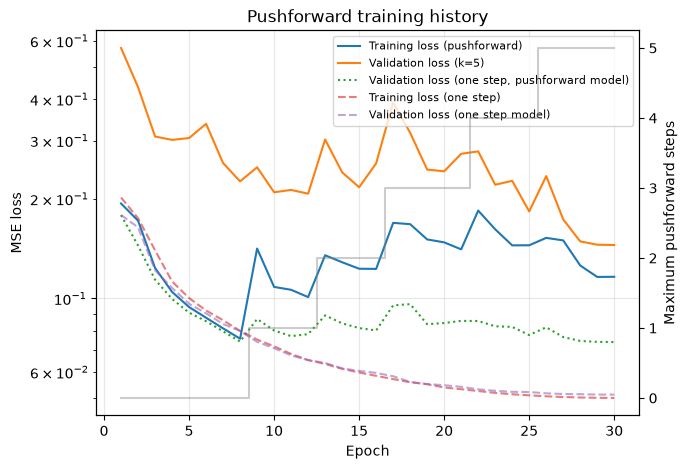

In [103]:
epochs = np.arange(
    1,
    len(pushforward_train_losses) + 1,
)

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(
    epochs,
    pushforward_train_losses,
    label="Training loss (pushforward)",
)

ax.plot(
    epochs,
    pushforward_val_losses,
    label=f"Validation loss (k={MAX_PUSHFORWARD_STEPS})",
)

ax.plot(
    epochs,
    pushforward_one_step_val_losses,
    ":",
    label="Validation loss (one step, pushforward model)",
)

ax.plot(
    epochs,
    slice_train_losses,
    "--",
    alpha=0.6,
    label="Training loss (one step)",
)

ax.plot(
    epochs,
    slice_val_losses,
    "--",
    alpha=0.6,
    label="Validation loss (one step model)",
)

ax.set_xlabel("Epoch")
ax.set_ylabel("MSE loss")
ax.set_yscale("log")
ax.set_title("Pushforward training history")
ax.grid(alpha=0.3)
ax.legend(fontsize=8)

horizon_ax = ax.twinx()

horizon_ax.step(
    epochs,
    pushforward_horizons,
    where="mid",
    color="grey",
    alpha=0.4,
)

horizon_ax.set_ylabel("Maximum pushforward steps")
horizon_ax.set_yticks(range(MAX_PUSHFORWARD_STEPS + 1))

plt.show()

In [104]:
pushforward_test_results = evaluate_one_step(
    model=pushforward_transformer,
    loader=test_loader,
    mean=omega_mean,
    std=omega_std,
    device=device,
)

print("Pushforward physics-slice Transformer one-step test results")

for metric, value in pushforward_test_results.items():
    print(f"{metric:12s}: {value:.6e}")

Pushforward physics-slice Transformer one-step test results
MSE         : 9.385472e-02
Relative L2 : 1.957957e-01


In [105]:
(
    pushforward_rollout_errors,
    pushforward_teacher_forcing_errors,
) = evaluate_rollouts(
    model=pushforward_transformer,
    trajectory_indices=test_indices,
    initial_vorticity=initial_vorticity,
    vorticity=vorticity,
    spatial_stride=SPATIAL_STRIDE,
    mean=omega_mean,
    std=omega_std,
    device=device,
    n_steps=20,
)

print("Autoregressive errors:", pushforward_rollout_errors.shape)
print("Teacher-forced errors:", pushforward_teacher_forcing_errors.shape)

Autoregressive errors: (200, 21)
Teacher-forced errors: (200, 21)


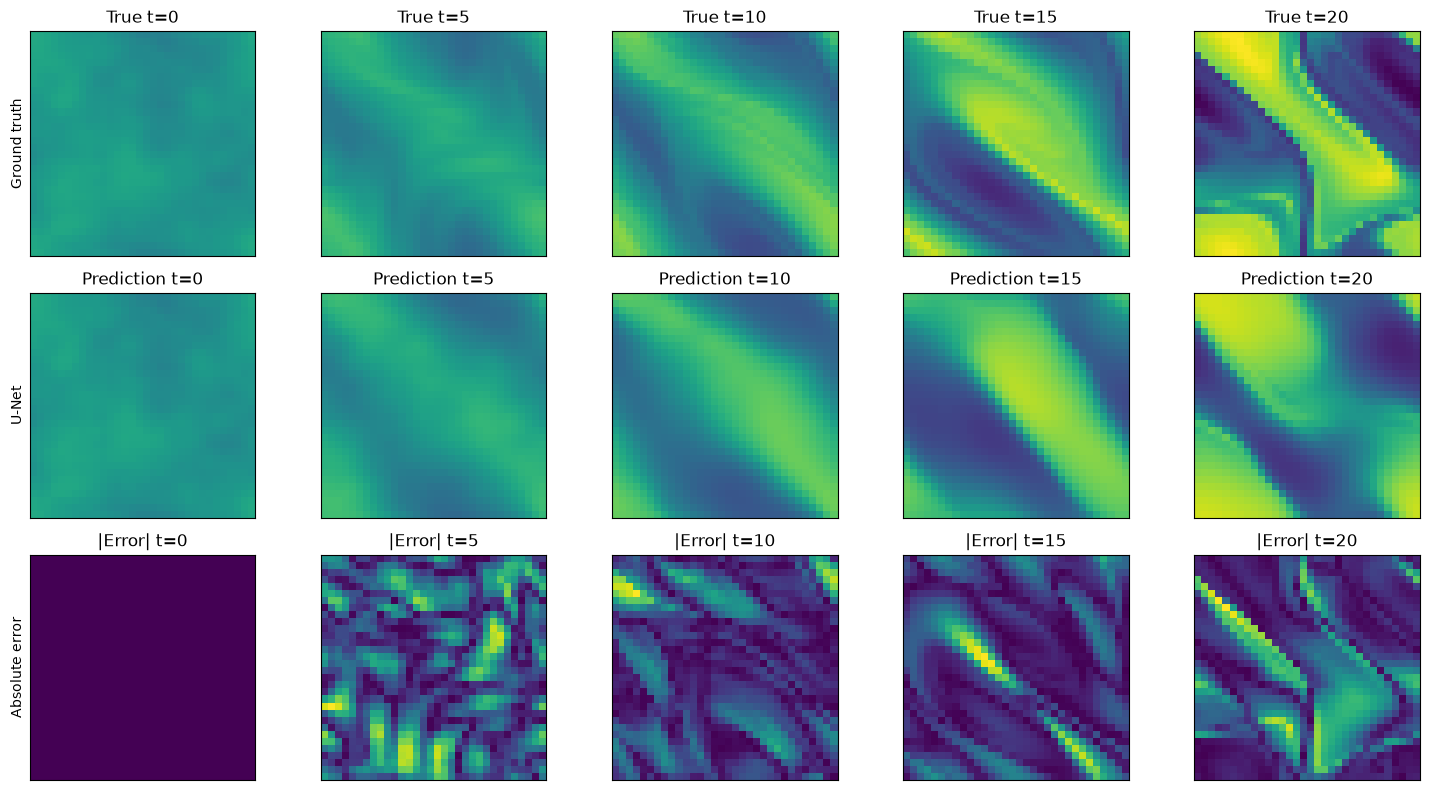

In [106]:
trajectory_idx = test_indices[1]

true_trajectory = get_trajectory(
    trajectory_idx=trajectory_idx,
    initial_vorticity=initial_vorticity,
    vorticity=vorticity,
    spatial_stride=SPATIAL_STRIDE,
)

pred_trajectory = rollout_model(
    model=pushforward_transformer,
    initial_state=true_trajectory[0],
    n_steps=20,
    mean=omega_mean,
    std=omega_std,
    device=device,
)

plot_rollout(
    true_trajectory,
    pred_trajectory,
)

In [107]:
print(
    f"{'Model':28s} "
    f"{'MSE':>14s} "
    f"{'Relative L2':>14s} "
    f"{'Rollout L2 @20':>16s}"
)

print("-" * 76)

for name, results, rollout_errors in [
    ("U-Net", unet_test_results, unet_rollout_errors),
    ("Transformer", transformer_test_results, transformer_rollout_errors),
    ("Physics-slice", slice_test_results, slice_rollout_errors),
    (
        "Physics-slice pushforward",
        pushforward_test_results,
        pushforward_rollout_errors,
    ),
]:
    print(
        f"{name:28s} "
        f"{results['MSE']:14.6e} "
        f"{results['Relative L2']:14.6e} "
        f"{rollout_errors.mean(axis=0)[-1]:16.6e}"
    )

Model                                   MSE    Relative L2   Rollout L2 @20
----------------------------------------------------------------------------
U-Net                          2.644214e-02   1.353959e-01     1.258480e+00
Transformer                    2.375252e-02   1.014822e-01     6.404405e-01
Physics-slice                  6.583752e-02   1.730571e-01     6.769428e-01
Physics-slice pushforward      9.385472e-02   1.957957e-01     5.894514e-01


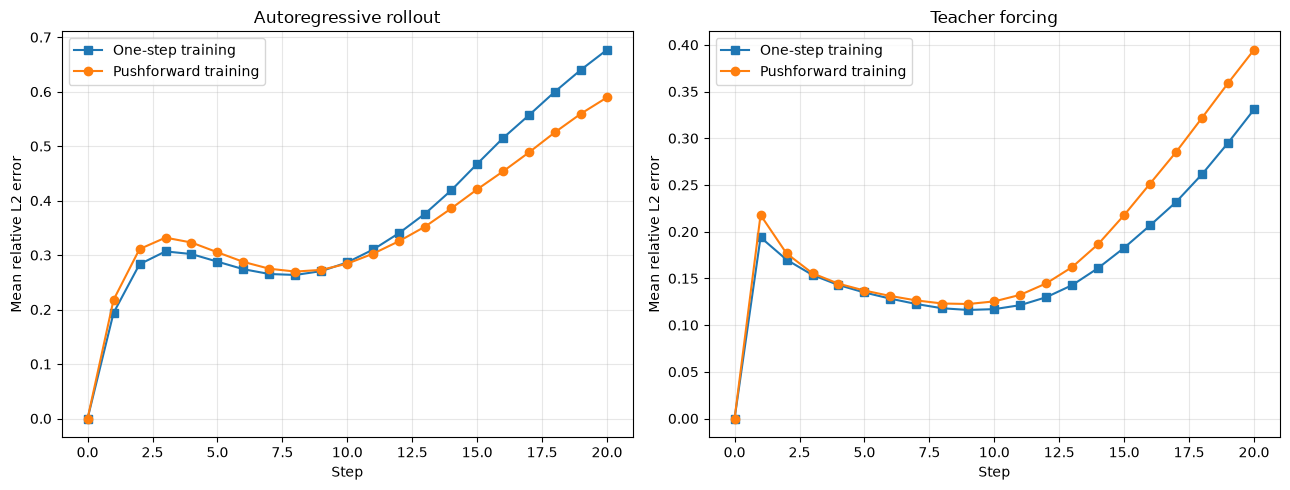

In [108]:
steps = np.arange(
    slice_rollout_errors.shape[1]
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5),
)

axes[0].plot(
    steps,
    slice_rollout_errors.mean(axis=0),
    marker="s",
    label="One-step training",
)

axes[0].plot(
    steps,
    pushforward_rollout_errors.mean(axis=0),
    marker="o",
    label="Pushforward training",
)

axes[0].set_title("Autoregressive rollout")

axes[1].plot(
    steps,
    slice_teacher_forcing_errors.mean(axis=0),
    marker="s",
    label="One-step training",
)

axes[1].plot(
    steps,
    pushforward_teacher_forcing_errors.mean(axis=0),
    marker="o",
    label="Pushforward training",
)

axes[1].set_title("Teacher forcing")

for ax in axes:
    ax.set_xlabel("Step")
    ax.set_ylabel("Mean relative L2 error")
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

In [109]:
# Relative change of the rollout error, step by step. Values below 1 mean the
# pushforward model is the more stable of the two at that horizon.
ratio = (
    pushforward_rollout_errors.mean(axis=0)[1:]
    / slice_rollout_errors.mean(axis=0)[1:]
)

for step, value in enumerate(ratio, start=1):
    print(f"step {step:2d}: pushforward / one-step = {value:.3f}")

step  1: pushforward / one-step = 1.123
step  2: pushforward / one-step = 1.098
step  3: pushforward / one-step = 1.082
step  4: pushforward / one-step = 1.070
step  5: pushforward / one-step = 1.060
step  6: pushforward / one-step = 1.049
step  7: pushforward / one-step = 1.036
step  8: pushforward / one-step = 1.024
step  9: pushforward / one-step = 1.008
step 10: pushforward / one-step = 0.992
step 11: pushforward / one-step = 0.975
step 12: pushforward / one-step = 0.956
step 13: pushforward / one-step = 0.937
step 14: pushforward / one-step = 0.920
step 15: pushforward / one-step = 0.900
step 16: pushforward / one-step = 0.881
step 17: pushforward / one-step = 0.877
step 18: pushforward / one-step = 0.876
step 19: pushforward / one-step = 0.874
step 20: pushforward / one-step = 0.871
